# Section 4: Final Custom K-Means Analysis

This notebook analyzes the **final version** of `KMeansCustom` used in the project.

The final custom algorithm works as follows:

1. initialize centroids with deterministic dominant-axis percentile-based ESPI placement
2. assign all points to the nearest centroid
3. update centroids from cluster means
4. repeat full reassignment and centroid updates
5. compute centroid drift after each update
6. use the maximum drift only as the **stopping criterion**

This notebook compares the final custom model with:

- `KMeansAlternate`
- simple k-means with random initialization
- k-means++

across the three project datasets and multiple values of `k`.


In [1]:
# Section 4: Imports and module reload for custom/alternate K-Means analysis.
# We reload so notebook reflects latest changes to kmeans_custom.py and kmeans_alternate.py.
import inspect
import importlib
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import kmeans_plusplus
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import kmeans_custom
import kmeans_alternate

importlib.reload(kmeans_custom)
importlib.reload(kmeans_alternate)

KMeansCustom = kmeans_custom.KMeansCustom
KMeansAlternate = kmeans_alternate.KMeansAlternate

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True


In [2]:
# Show file modification times and current percentile_init implementation for reference.
print("kmeans_custom.py last modified:", time.ctime(Path("kmeans_custom.py").stat().st_mtime))
print("kmeans_alternate.py last modified:", time.ctime(Path("kmeans_alternate.py").stat().st_mtime))
print()
print("Current percentile_init source:")
print(inspect.getsource(KMeansCustom.percentile_init))


kmeans_custom.py last modified: Mon Mar  2 06:22:20 2026
kmeans_alternate.py last modified: Mon Mar  2 06:22:28 2026

Current percentile_init source:
    def percentile_init(self, data):
        variances = np.var(data, axis=0)
        dominant_dim = int(np.argmax(variances))

        base_centroid = np.mean(data, axis=0)
        low = np.percentile(data[:, dominant_dim], self.low_percentile)
        high = np.percentile(data[:, dominant_dim], self.high_percentile)

        centroids = np.tile(base_centroid, (self.k, 1))
        for j in range(self.k):
            t = (j + 0.5) / self.k
            centroids[j, dominant_dim] = low + t * (high - low)

        return centroids



In [3]:
# Load and preprocess the three project datasets; output a summary table of rows and features.
def load_datasets():
    """Load Iris, AI Index, and Earthquakes DataFrames from data/."""
    iris = pd.read_csv("data/iris.csv")
    ai = pd.read_csv("data/ai_index.csv")
    eq = pd.read_csv("data/earthquakes.csv")
    return iris, ai, eq


def preprocess_iris(df):
    """Drop species, dropna, then standardize features."""
    df = df.drop(columns=["species"]).dropna()
    return StandardScaler().fit_transform(df)


def preprocess_ai(df):
    """Keep numeric columns only, dropna, then standardize."""
    df = df.select_dtypes(include=[np.number]).dropna()
    return StandardScaler().fit_transform(df)


def preprocess_eq(df):
    """Keep magnitude, depth, lat, lon; dropna; standardize."""
    df = df[["magnitude", "depth", "latitude", "longitude"]].dropna()
    return StandardScaler().fit_transform(df)


iris_df, ai_df, eq_df = load_datasets()

datasets = {
    "Iris (D1)": preprocess_iris(iris_df),
    "AI Index (D2)": preprocess_ai(ai_df),
    "Earthquakes (D3)": preprocess_eq(eq_df),
}

pd.DataFrame(
    [
        {"Dataset": name, "Rows": data.shape[0], "Features": data.shape[1]}
        for name, data in datasets.items()
    ]
)


,Dataset,Rows,Features
0,Iris (D1),150,4
1,AI Index (D2),62,8
2,Earthquakes (D3),1137,4


In [4]:
class StandardKMeansTracker:
    """
    Textbook k-means with full reassignment each iteration.
    init='random' -> simple k-means
    init='k-means++' -> k-means++
    """

    def __init__(self, k, init="random", max_iterations=100, random_state=42):
        self.k = k
        self.init = init
        self.max_iterations = max_iterations
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.sse_history = []
        self.reassigned_history = []
        self.n_iterations = 0

    def _init_centroids(self, data):
        if self.init == "k-means++":
            centroids, _ = kmeans_plusplus(data, n_clusters=self.k, random_state=self.random_state)
            return centroids
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(len(data), self.k, replace=False)
        return data[indices].copy()

    @staticmethod
    def _assign_all(data, centroids):
        diffs = data[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        dists = np.sqrt(np.sum(diffs ** 2, axis=2))
        return np.argmin(dists, axis=1)

    @staticmethod
    def _compute_sse(data, labels, centroids, k):
        sse = 0.0
        for i in range(k):
            pts = data[labels == i]
            if len(pts) > 0:
                sse += np.sum((pts - centroids[i]) ** 2)
        return float(sse)

    def fit(self, data):
        data = np.asarray(data, dtype=float)
        self.sse_history = []
        self.reassigned_history = []
        self.n_iterations = 0

        self.centroids = self._init_centroids(data)
        self.labels = self._assign_all(data, self.centroids)

        for _ in range(self.max_iterations):
            new_centroids = np.empty_like(self.centroids)
            for i in range(self.k):
                pts = data[self.labels == i]
                if len(pts) == 0:
                    new_centroids[i] = self.centroids[i]
                else:
                    new_centroids[i] = pts.mean(axis=0)

            new_labels = self._assign_all(data, new_centroids)
            reassigned = int(np.sum(new_labels != self.labels))

            self.centroids = new_centroids
            self.labels = new_labels
            self.sse_history.append(self._compute_sse(data, self.labels, self.centroids, self.k))
            self.reassigned_history.append(reassigned)
            self.n_iterations += 1

            if reassigned == 0:
                break

        return self


def run_model(model_name, data, k):
    if model_name == "Custom (Final)":
        model = KMeansCustom(k=k, max_iterations=100, epsilon=1e-4)
        model.fit(data)
        final_sse = float(model.compute_sse(data))
        drift_history = list(model.drift_history)
    elif model_name == "Alternate":
        np.random.seed(42)
        model = KMeansAlternate(k=k, max_iterations=100)
        model.fit(data)
        final_sse = float(model.compute_sse(data))
        drift_history = None
    elif model_name == "Simple K-Means":
        model = StandardKMeansTracker(k=k, init="random", random_state=42)
        model.fit(data)
        final_sse = float(model.sse_history[-1])
        drift_history = None
    elif model_name == "K-Means++":
        model = StandardKMeansTracker(k=k, init="k-means++", random_state=42)
        model.fit(data)
        final_sse = float(model.sse_history[-1])
        drift_history = None
    else:
        raise ValueError(model_name)

    return model, final_sse, drift_history


## 4.1 Final Custom Algorithm Summary

The final custom algorithm is simpler than the earlier drift-filtering version.

- **Initialization**: centroids are placed deterministically along the dominant-variance feature using percentiles, while the other coordinates start from the global mean.
- **Assignment phase**: every point is reassigned in each iteration.
- **Update phase**: centroids are recomputed from the current labels.
- **Drift computation**: the movement of each centroid is measured after the update.
- **Stopping rule**: the algorithm stops when the maximum centroid drift falls below `epsilon`.

This means drift is now a **convergence measure**, not a point-pruning rule.


In [5]:
k_values = [2, 5, 10, 20]
model_names = ["Custom (Final)", "Alternate", "Simple K-Means", "K-Means++"]
model_colors = {
    "Custom (Final)": "#c0392b",
    "Alternate": "#2980b9",
    "Simple K-Means": "#27ae60",
    "K-Means++": "#f39c12",
}

all_results = {}
summary_rows = []
runtime_rows = []

for ds_name, data in datasets.items():
    for k in k_values:
        for model_name in model_names:
            start = time.perf_counter()
            model, final_sse, drift_history = run_model(model_name, data, k)
            runtime_value = time.perf_counter() - start

            all_results[(ds_name, k, model_name)] = {
                "labels": model.labels.copy(),
                "centroids": model.centroids.copy(),
                "sse_history": list(model.sse_history),
                "reassigned_history": list(model.reassigned_history),
                "n_iterations": model.n_iterations,
                "final_sse": final_sse,
                "runtime": runtime_value,
                "drift_history": drift_history,
            }

            summary_rows.append(
                {
                    "Dataset": ds_name,
                    "k": k,
                    "Model": model_name,
                    "Iterations": model.n_iterations,
                    "Final SSE": round(final_sse, 4),
                    "Total Reassignments": int(sum(model.reassigned_history)),
                    "Runtime (s)": runtime_value,
                }
            )
            if drift_history is not None:
                summary_rows[-1]["Final Max Drift"] = round(float(drift_history[-1]), 6) if drift_history else None

            runtime_rows.append(
                {
                    "Dataset": ds_name,
                    "k": k,
                    "Model": model_name,
                    "Runtime (s)": runtime_value,
                }
            )

comparison_summary_df = pd.DataFrame(summary_rows)
comparison_summary_df.head()


,Dataset,k,Model,Iterations,Final SSE,Total Reassignments,Runtime (s),Final Max Drift
0,Iris (D1),2,Custom (Final),3,223.7320,15,0.002337,0.0
1,Iris (D1),2,Alternate,2,223.7320,1,0.000547,NaN
2,Iris (D1),2,Simple K-Means,2,223.7320,1,0.000274,NaN
3,Iris (D1),2,K-Means++,6,223.7320,68,0.001219,NaN
4,Iris (D1),5,Custom (Final),7,106.6181,47,0.000472,0.0


## 4.2.1 Clustering Results for k = {2, 5, 10, 20}


Saved: Iris_(D1)_clustering.png


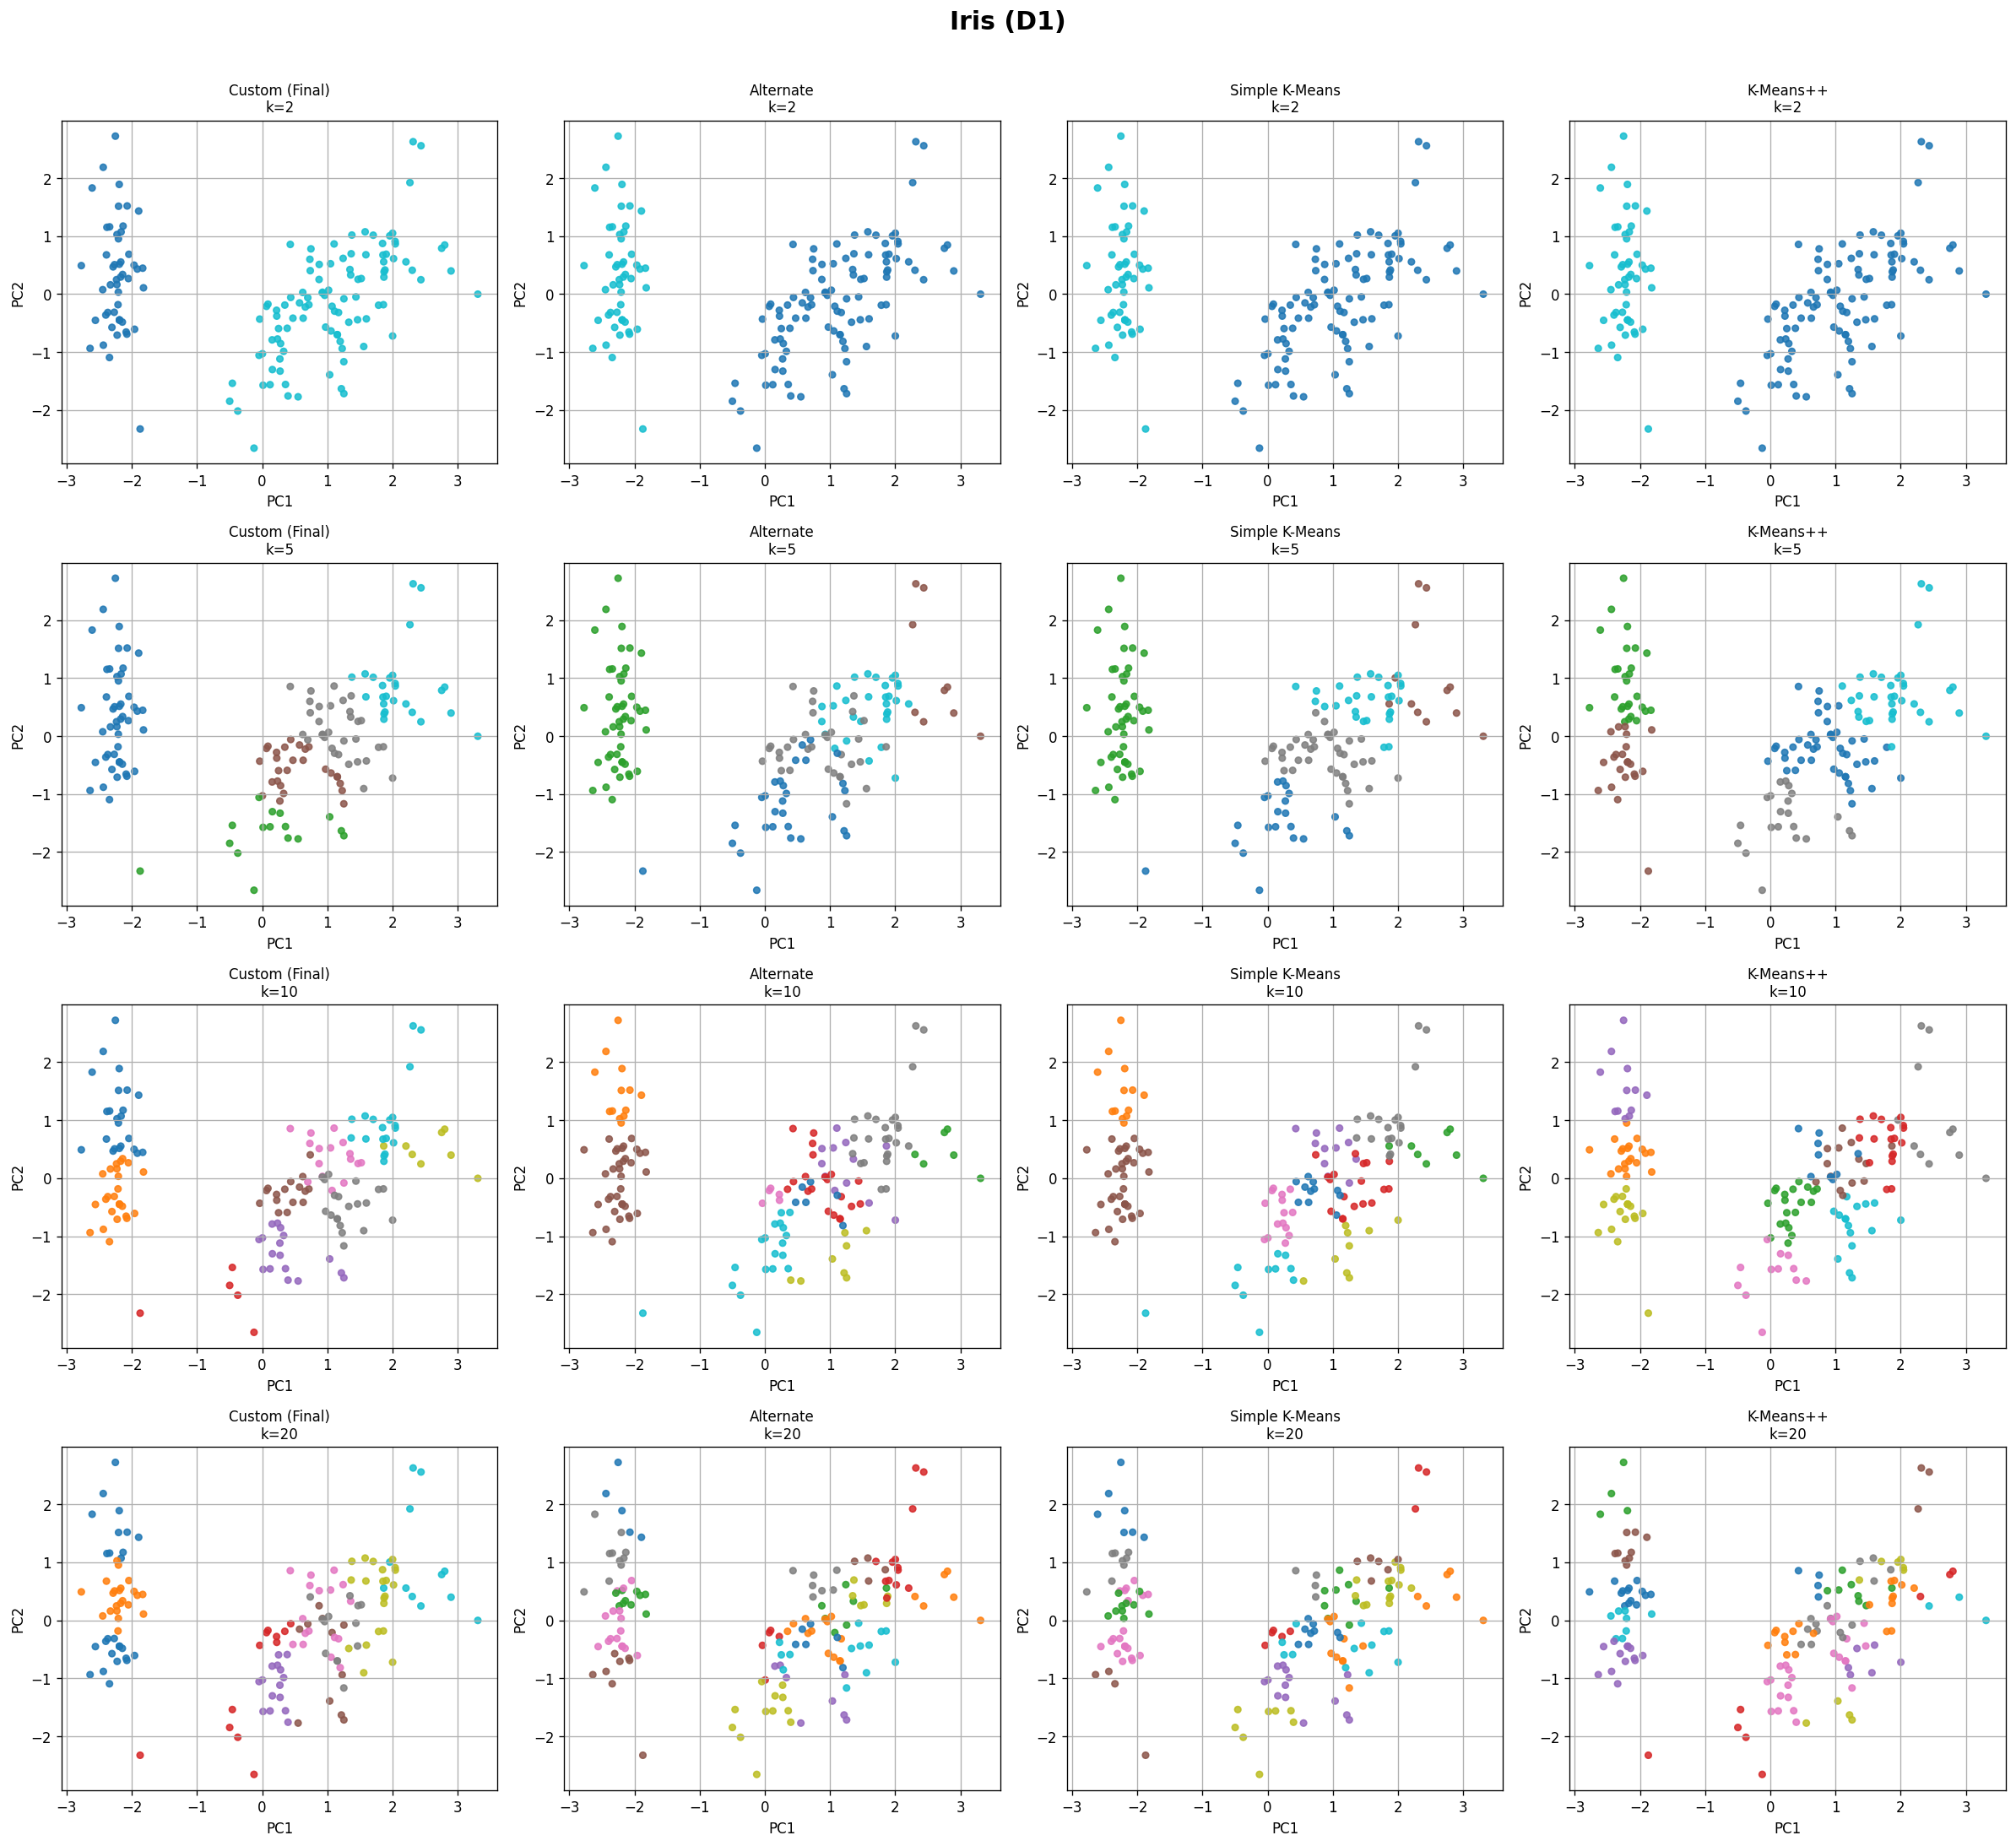

Saved: AI_Index_(D2)_clustering.png


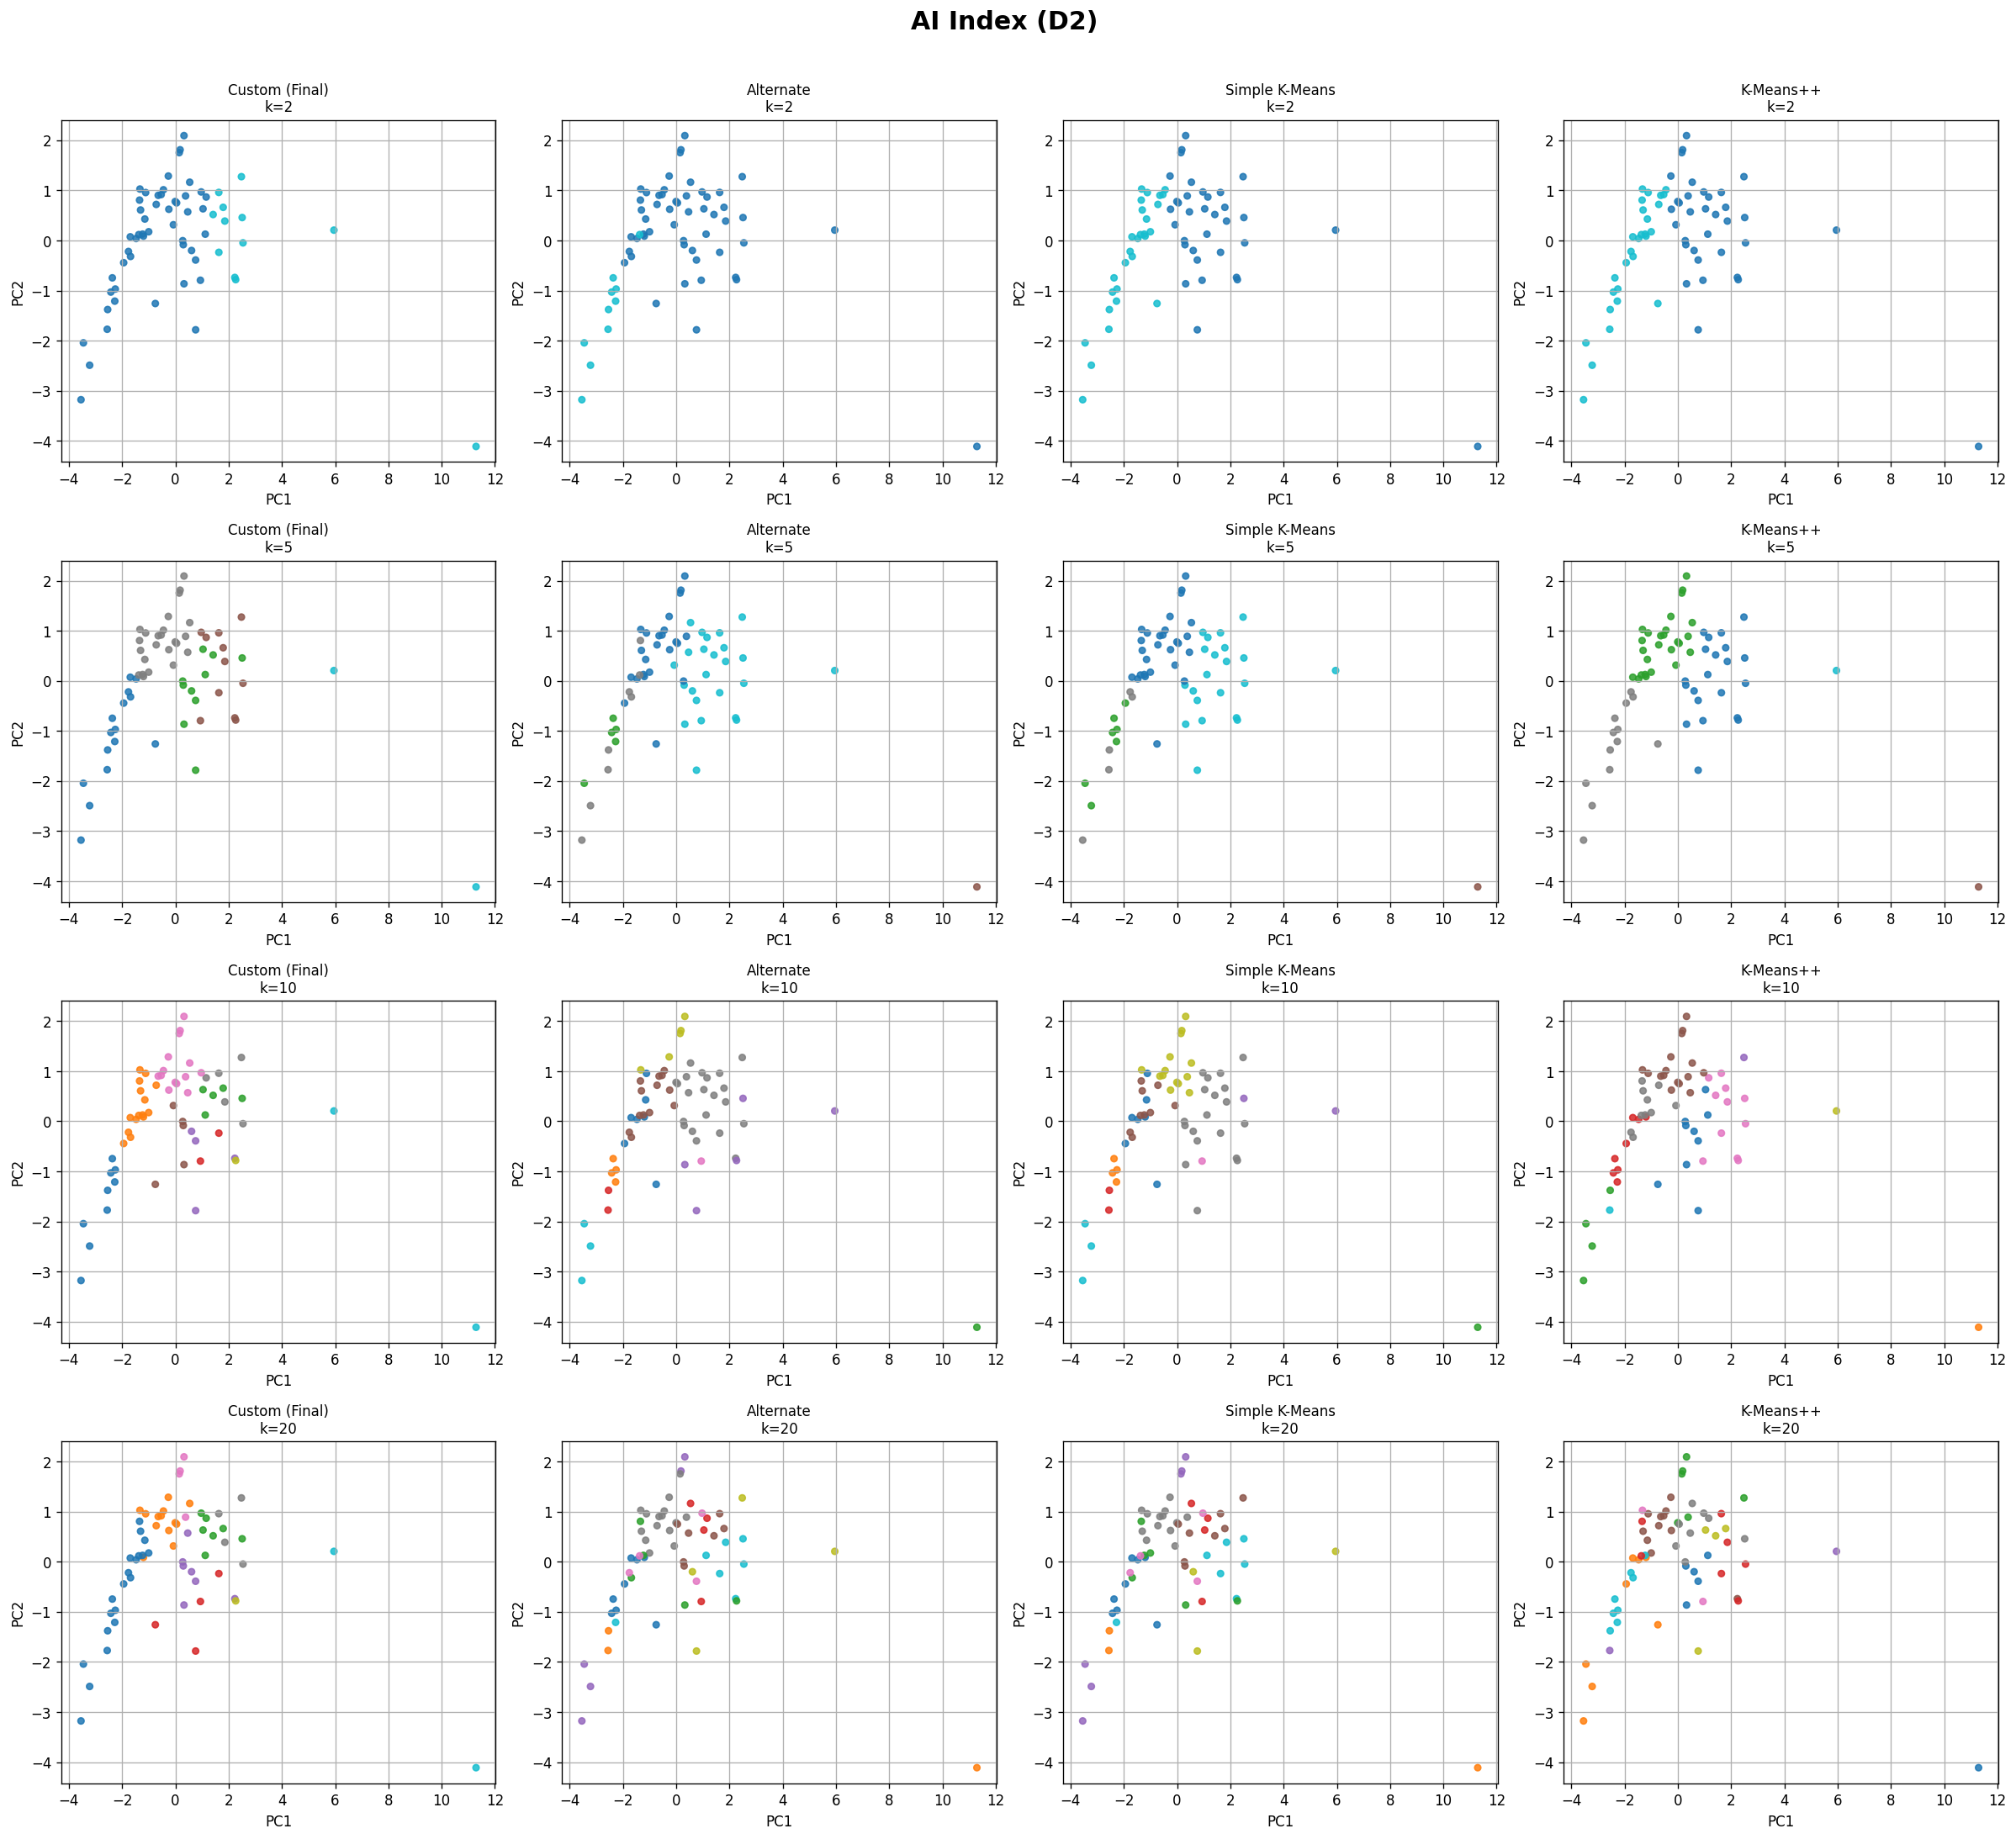

Saved: Earthquakes_(D3)_clustering.png


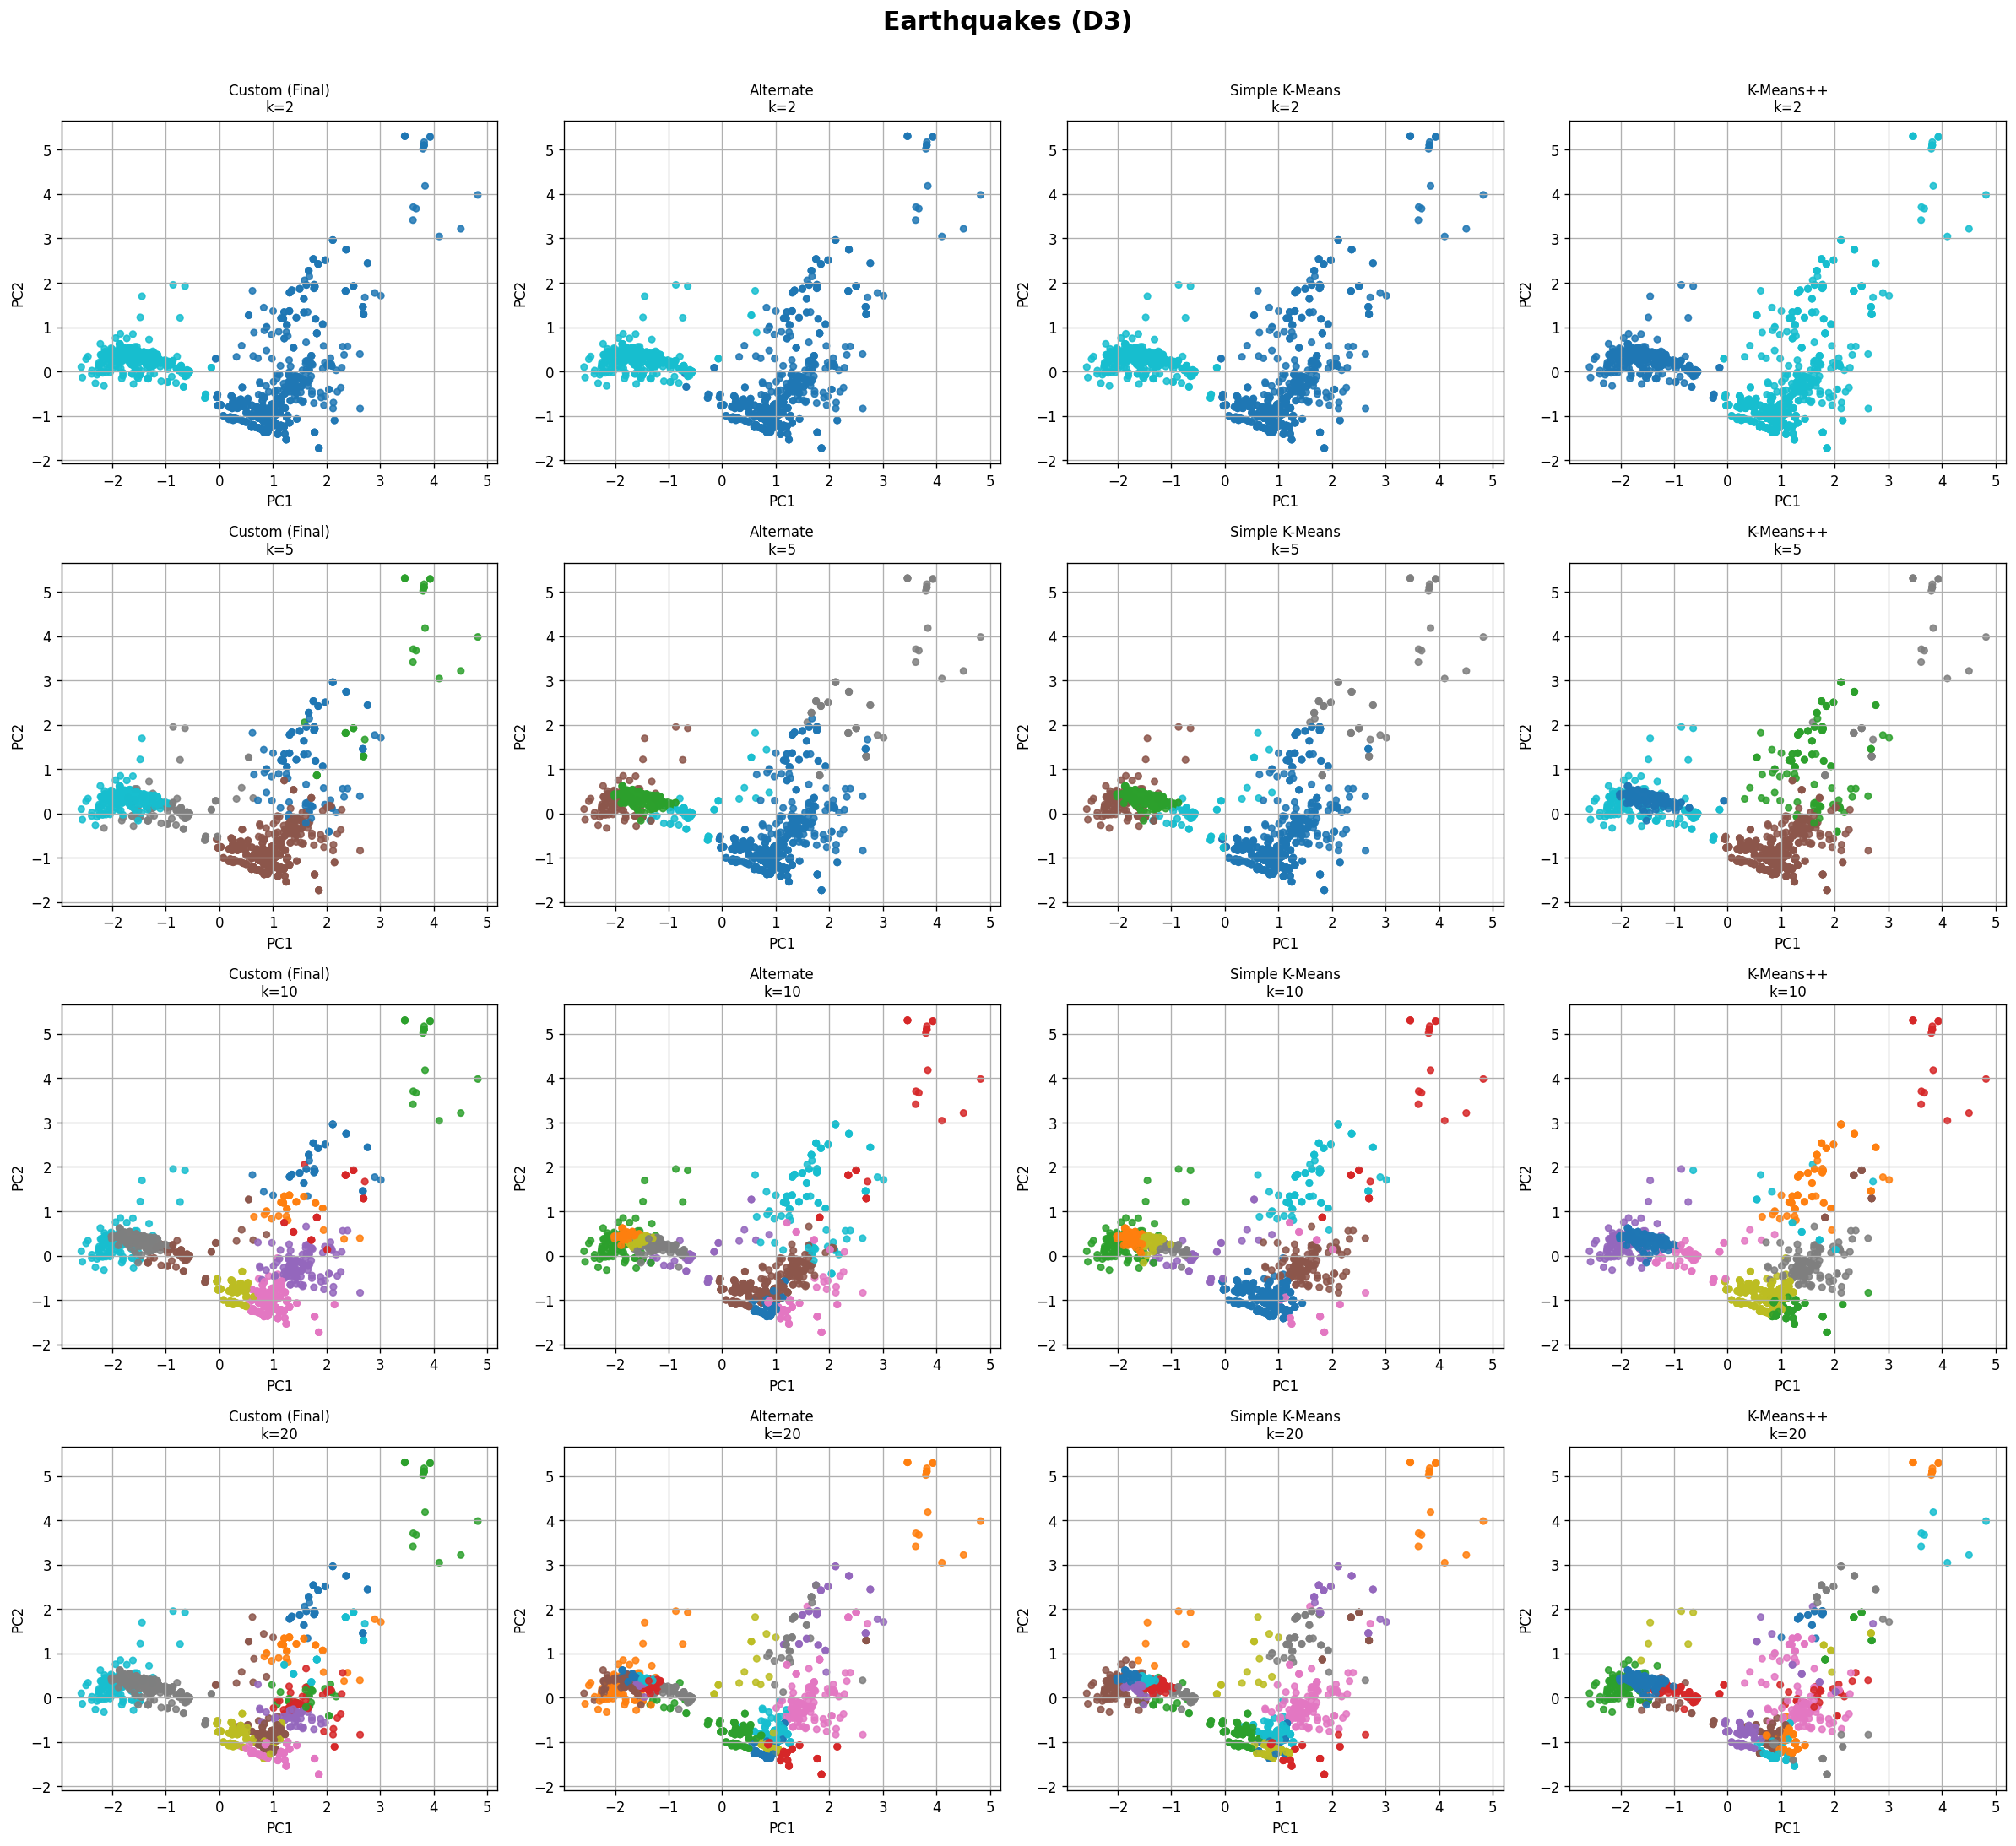

In [7]:
for ds_name, data in datasets.items():
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    fig, axes = plt.subplots(len(k_values), len(model_names), figsize=(20, 18))
    fig.suptitle(ds_name, fontsize=18, fontweight="bold", y=1.01)
    for row_idx, k in enumerate(k_values):
        for col_idx, model_name in enumerate(model_names):
            ax = axes[row_idx, col_idx]
            res = all_results[(ds_name, k, model_name)]
            ax.scatter(data_2d[:, 0], data_2d[:, 1], c=res["labels"], cmap="tab10", s=20, alpha=0.85)
            ax.set_title(f"{model_name}\nk={k}", fontsize=10)
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
    plt.tight_layout()
    
    # Save to file
    filename = f"{ds_name.replace(' ', '_')}_clustering.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved: {filename}")
    
    plt.show()  # Show in Jupyter

## 4.2.2 Convergence Behavior (SSE vs Iteration)


Saved: convergence/Iris_(D1)_sse_convergence.png


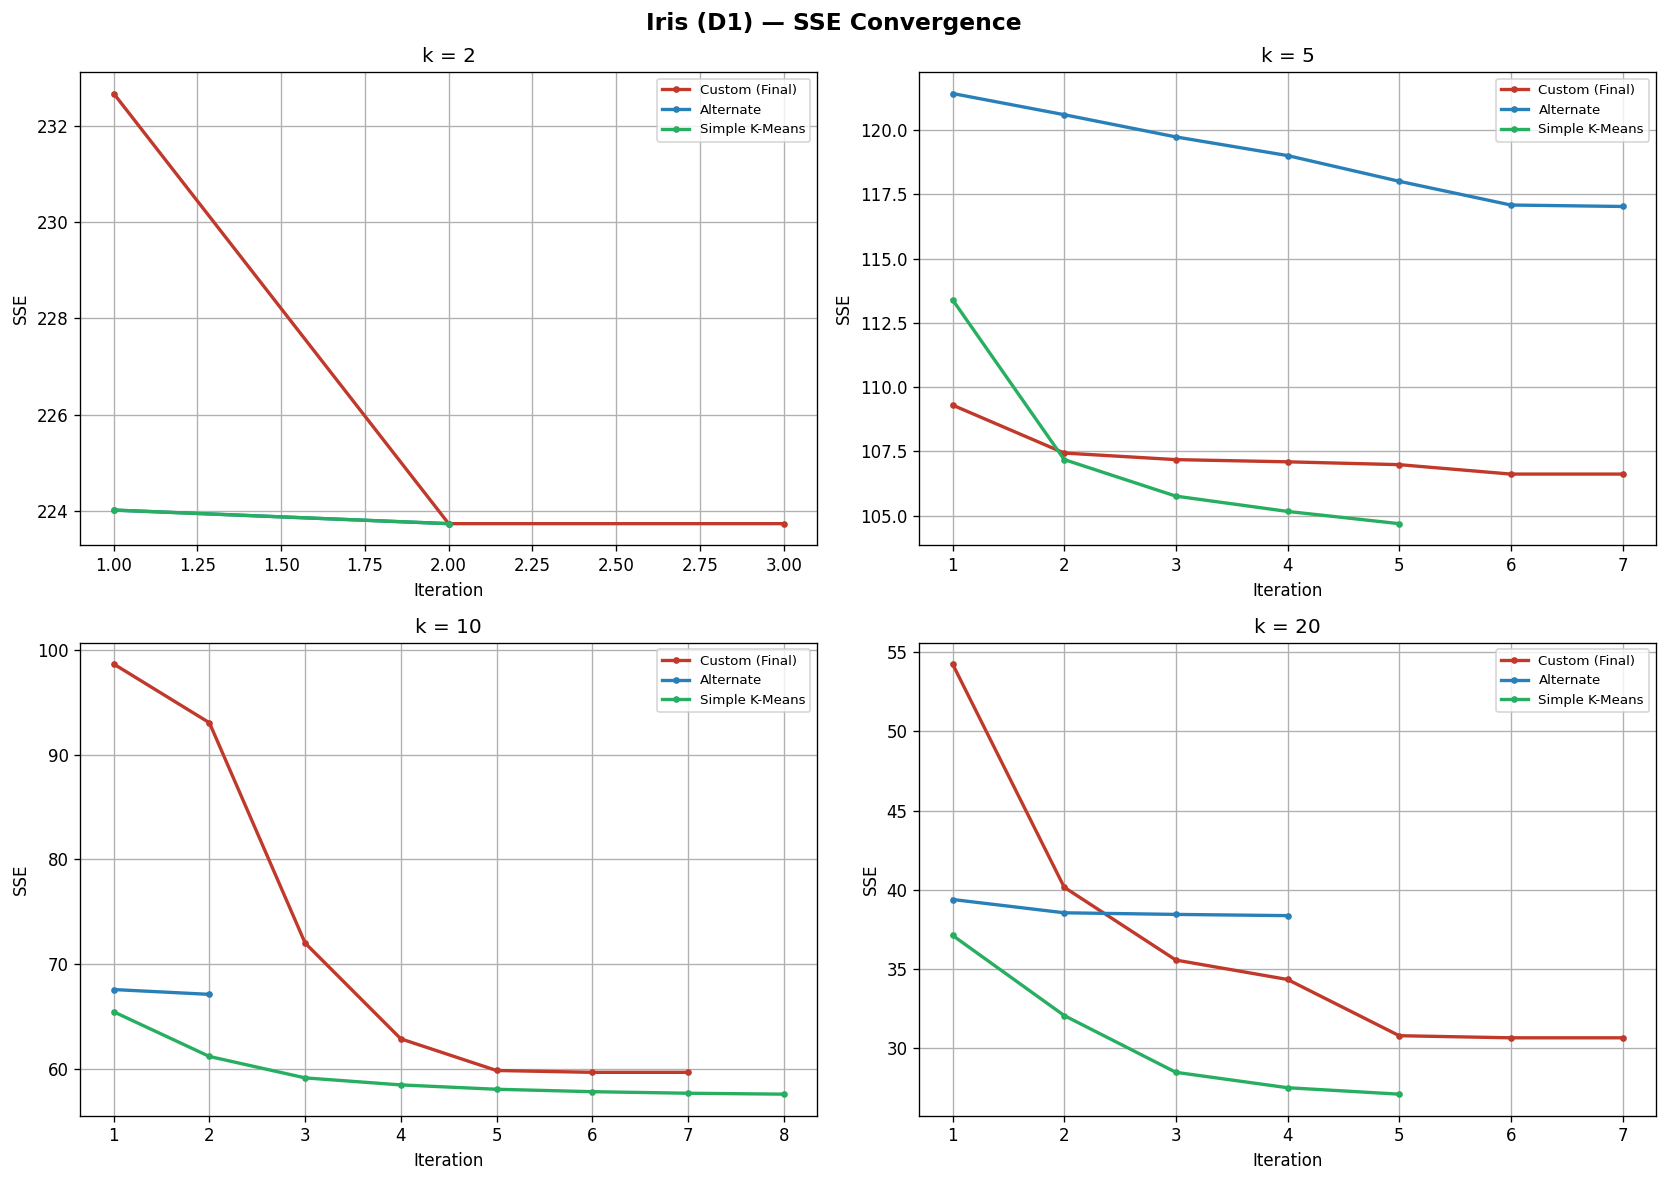

Saved: convergence/AI_Index_(D2)_sse_convergence.png


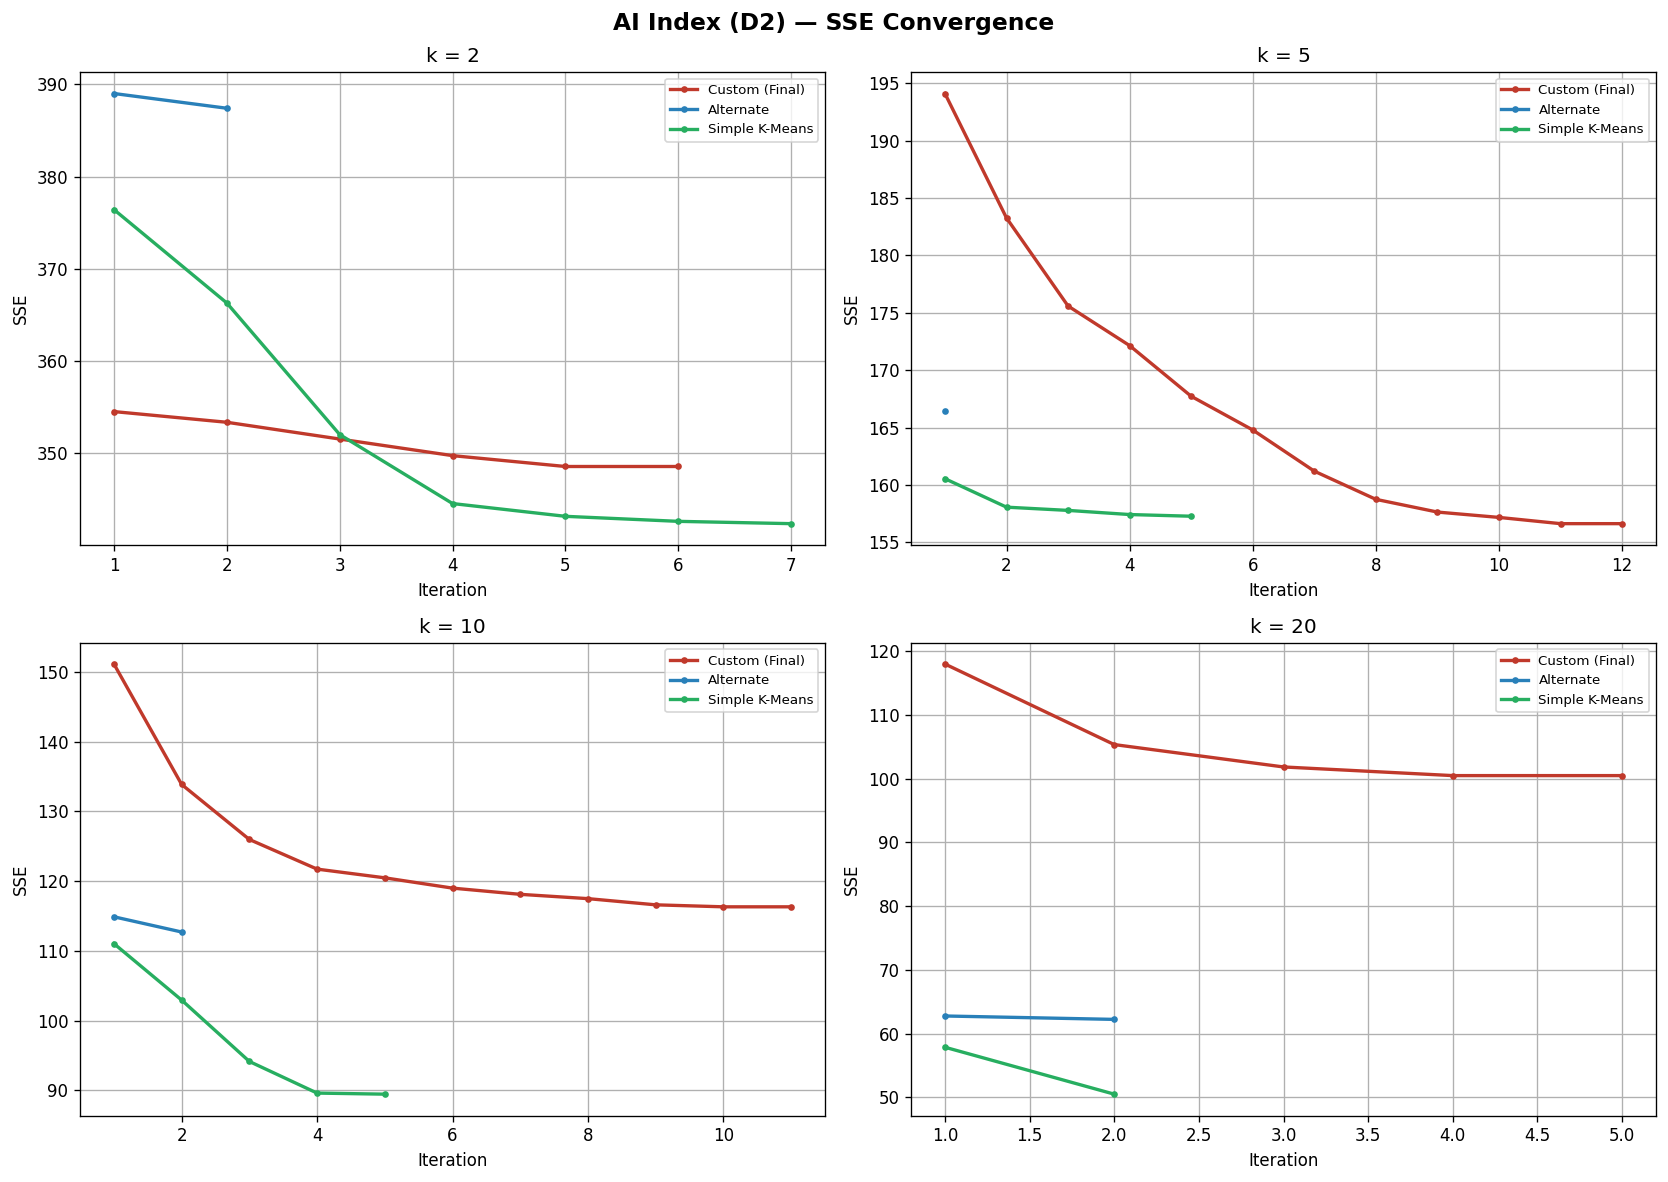

Saved: convergence/Earthquakes_(D3)_sse_convergence.png


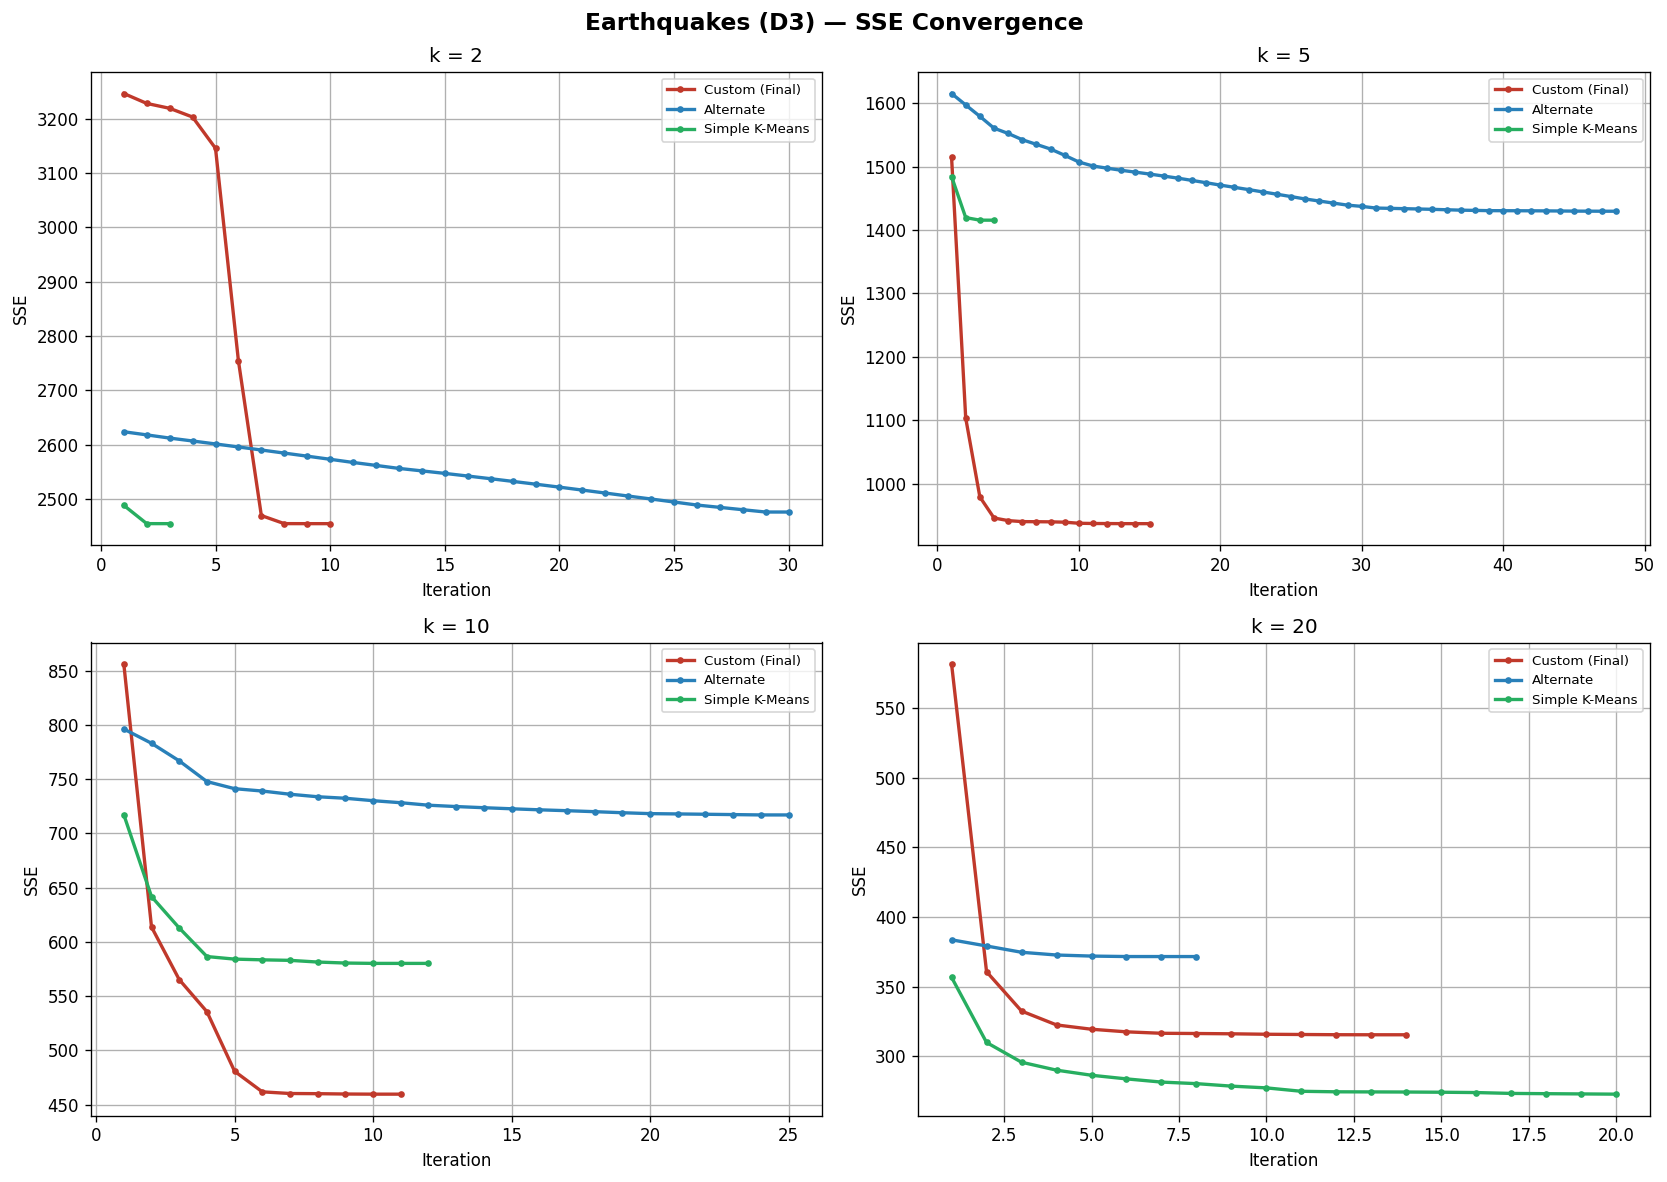

In [10]:
import os
os.makedirs("convergence", exist_ok=True)

for ds_name in datasets:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{ds_name} — SSE Convergence", fontsize=14, fontweight="bold")
    for idx, k in enumerate(k_values):
        ax = axes[idx // 2, idx % 2]
        for model_name in model_names:
            if model_name == "K-Means++":
                continue
            hist = all_results[(ds_name, k, model_name)]["sse_history"]
            ax.plot(
                range(1, len(hist) + 1),
                hist,
                color=model_colors[model_name],
                linewidth=2,
                marker="o",
                markersize=3,
                label=model_name,
            )
        ax.set_title(f"k = {k}")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("SSE")
        ax.legend(fontsize=8)
    plt.tight_layout()

    filename = f"convergence/{ds_name.replace(' ', '_')}_sse_convergence.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved: {filename}")

    plt.show()

## 4.2.3 Stability of Cluster Assignments


Saved: stability/Iris_(D1)_reassigned.png


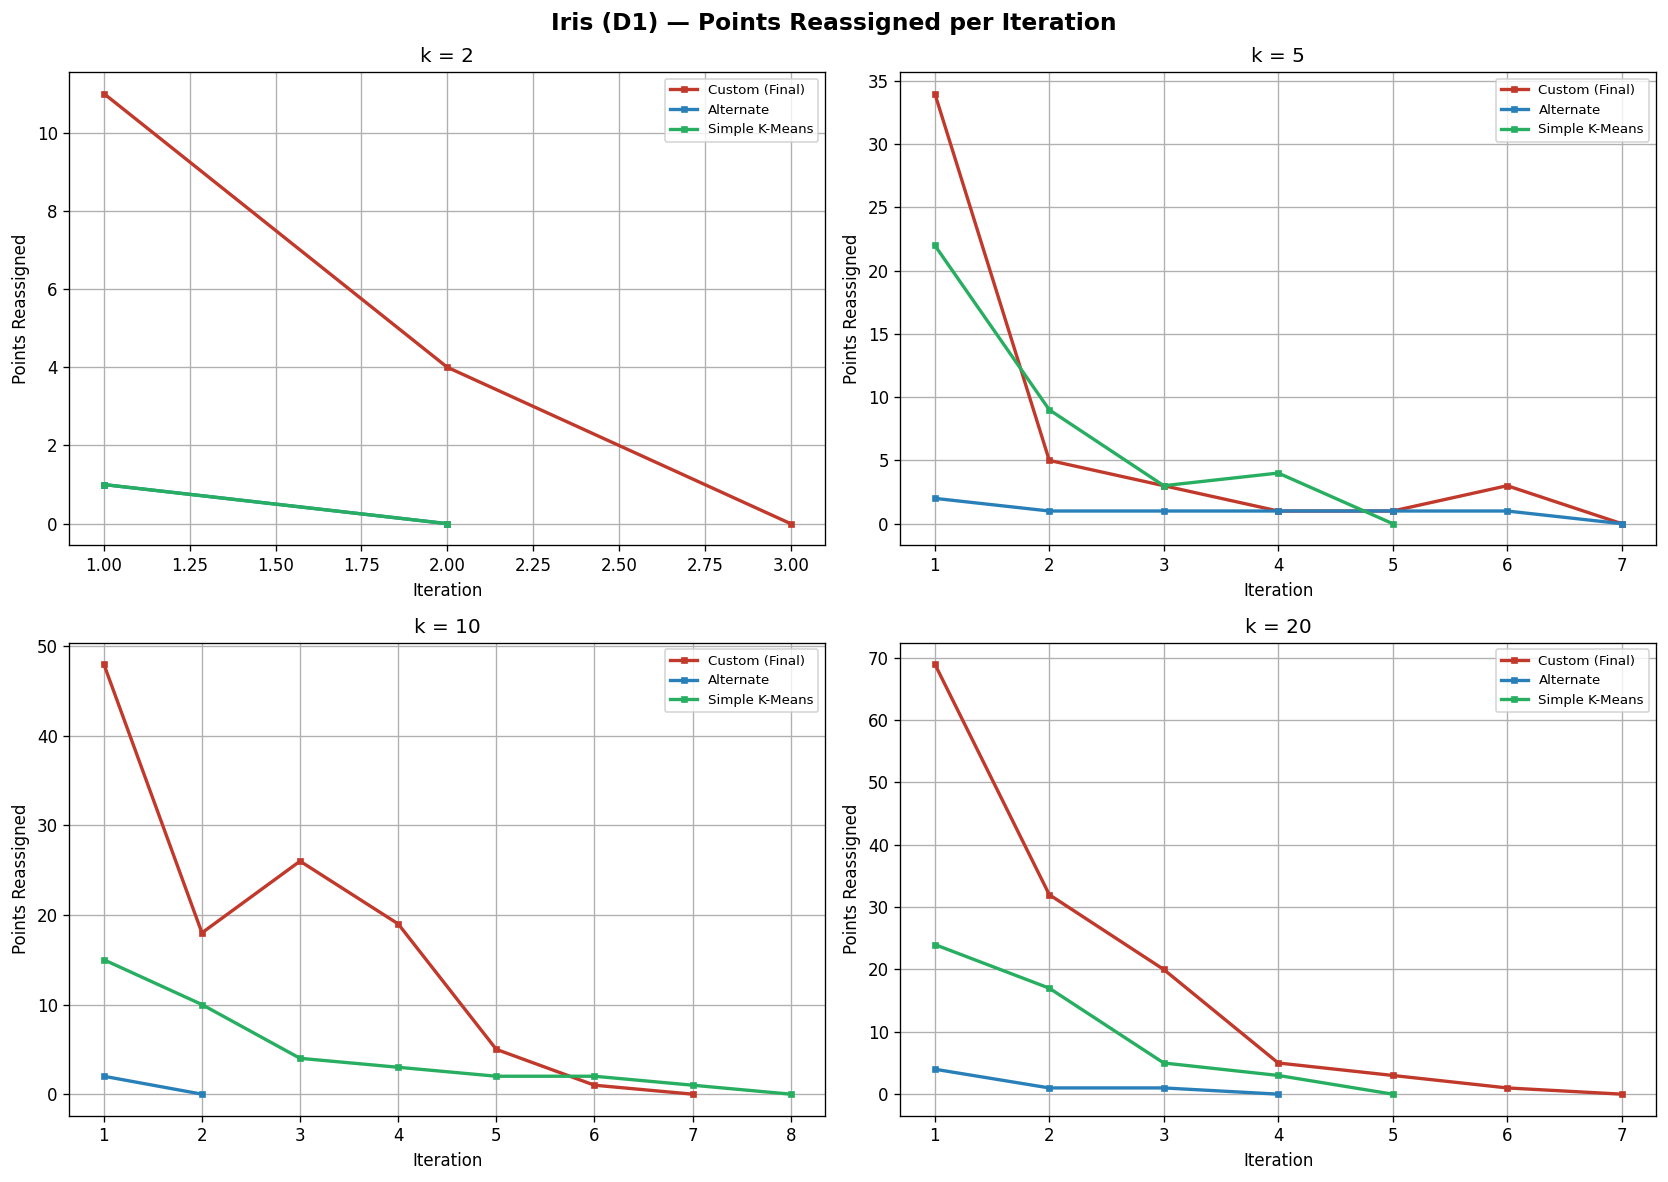

Saved: stability/AI_Index_(D2)_reassigned.png


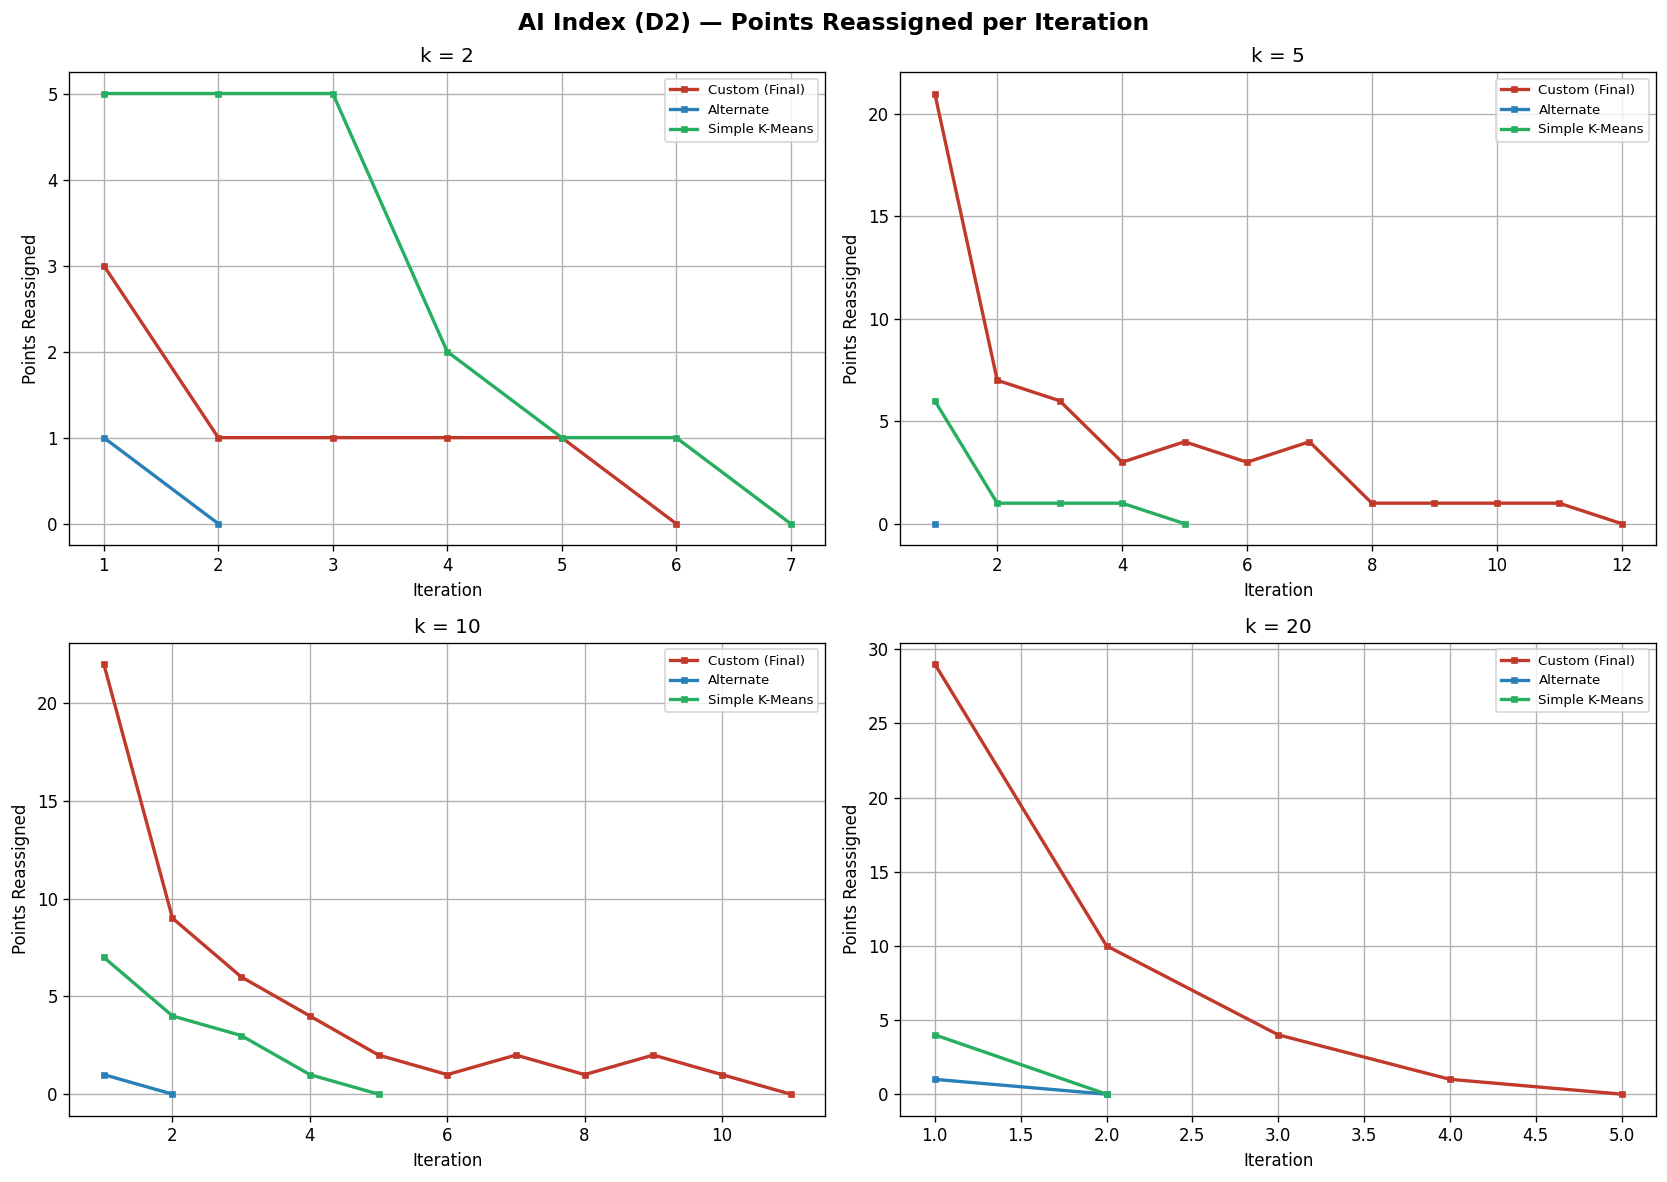

Saved: stability/Earthquakes_(D3)_reassigned.png


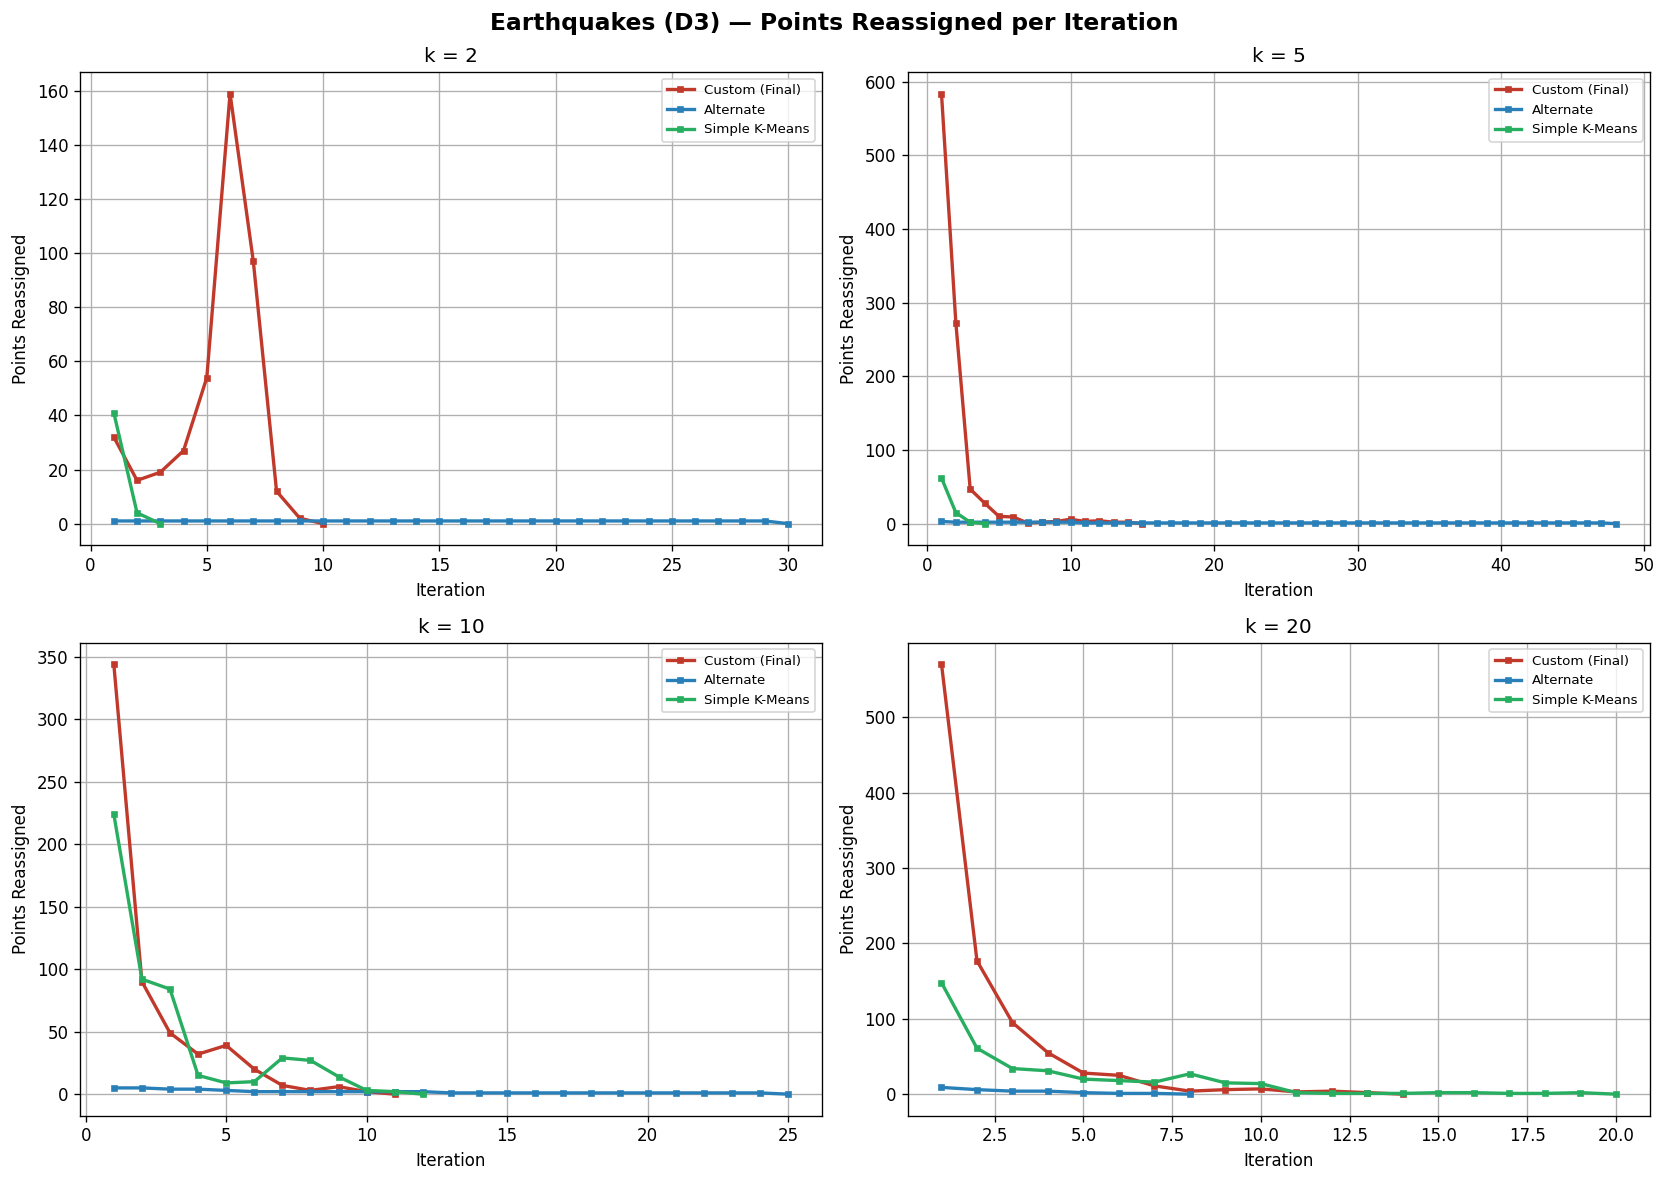

In [12]:
import os
os.makedirs("stability", exist_ok=True)

for ds_name in datasets:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{ds_name} — Points Reassigned per Iteration", fontsize=14, fontweight="bold")
    for idx, k in enumerate(k_values):
        ax = axes[idx // 2, idx % 2]
        for model_name in model_names:
            if model_name == "K-Means++":
                continue
            hist = all_results[(ds_name, k, model_name)]["reassigned_history"]
            ax.plot(
                range(1, len(hist) + 1),
                hist,
                color=model_colors[model_name],
                linewidth=2,
                marker="s",
                markersize=3,
                label=model_name,
            )
        ax.set_title(f"k = {k}")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Points Reassigned")
        ax.legend(fontsize=8)
    plt.tight_layout()

    filename = f"stability/{ds_name.replace(' ', '_')}_reassigned.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved: {filename}")

    plt.show()

## 4.2.4 Drift Behavior of the Final Custom Algorithm


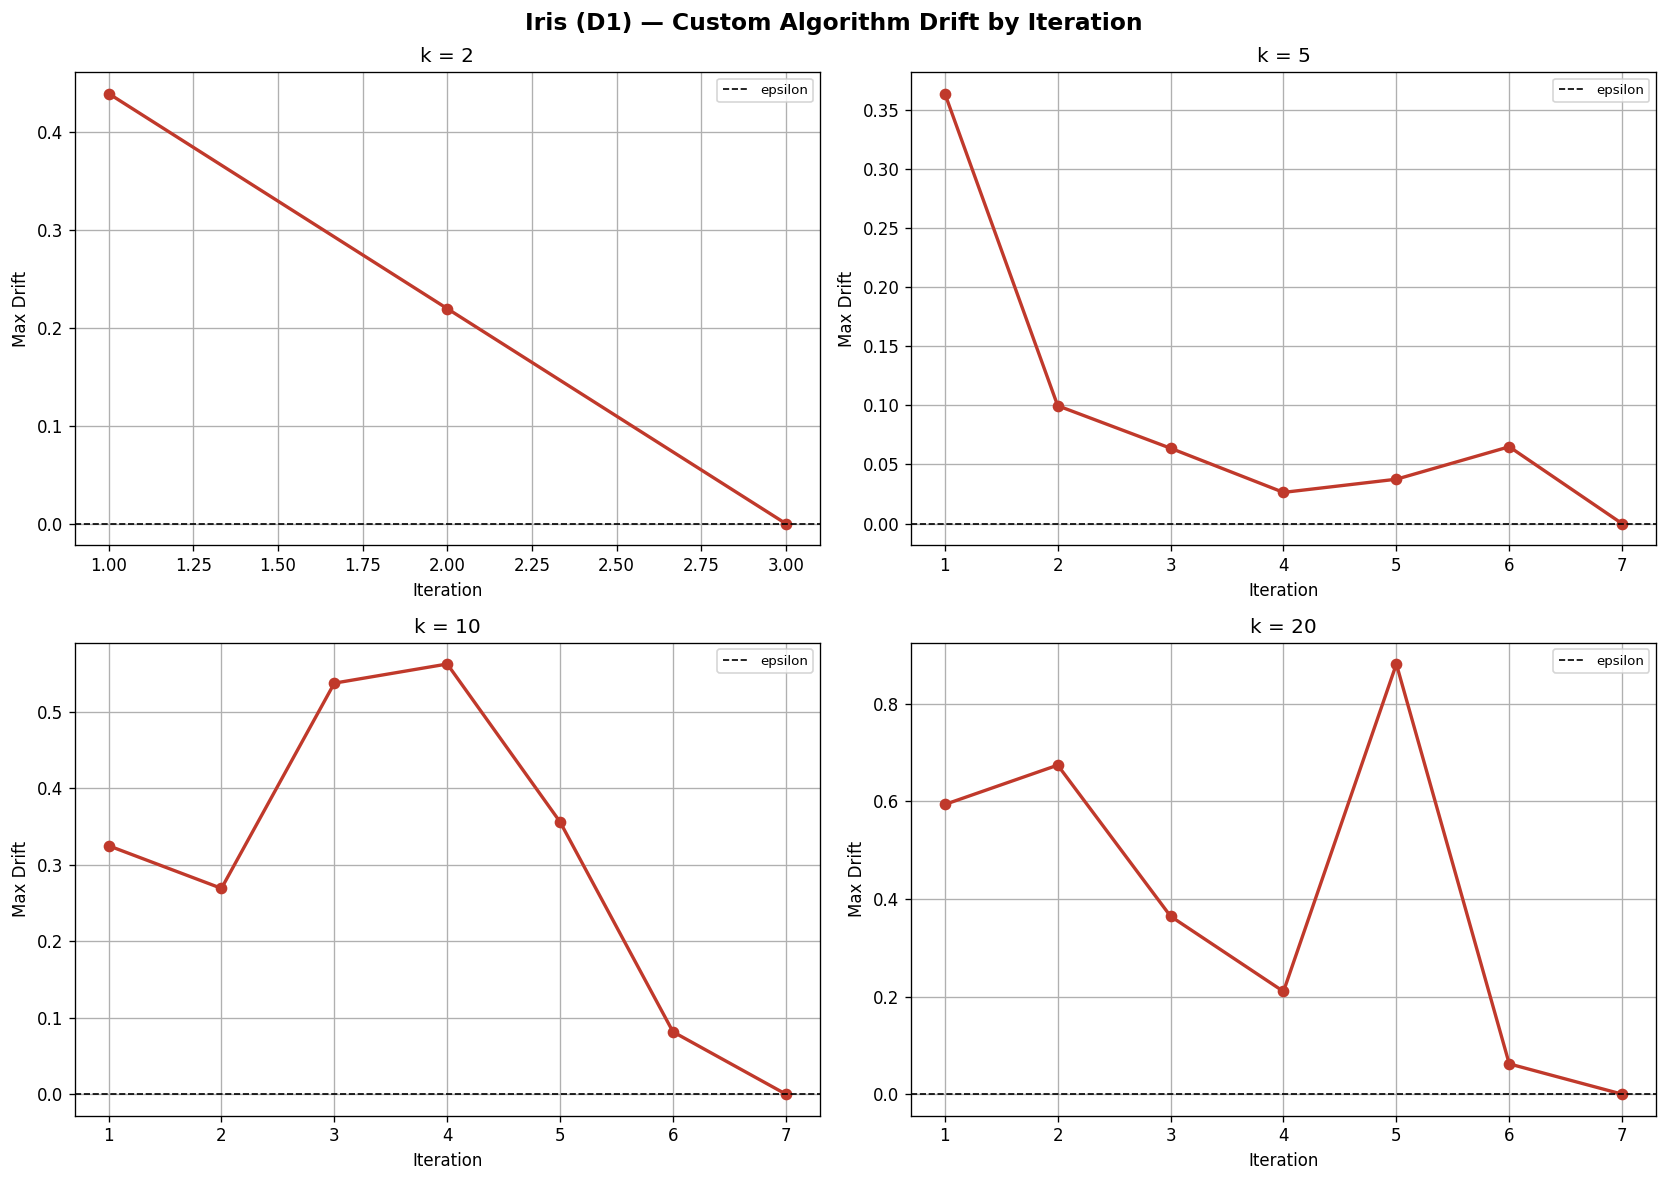

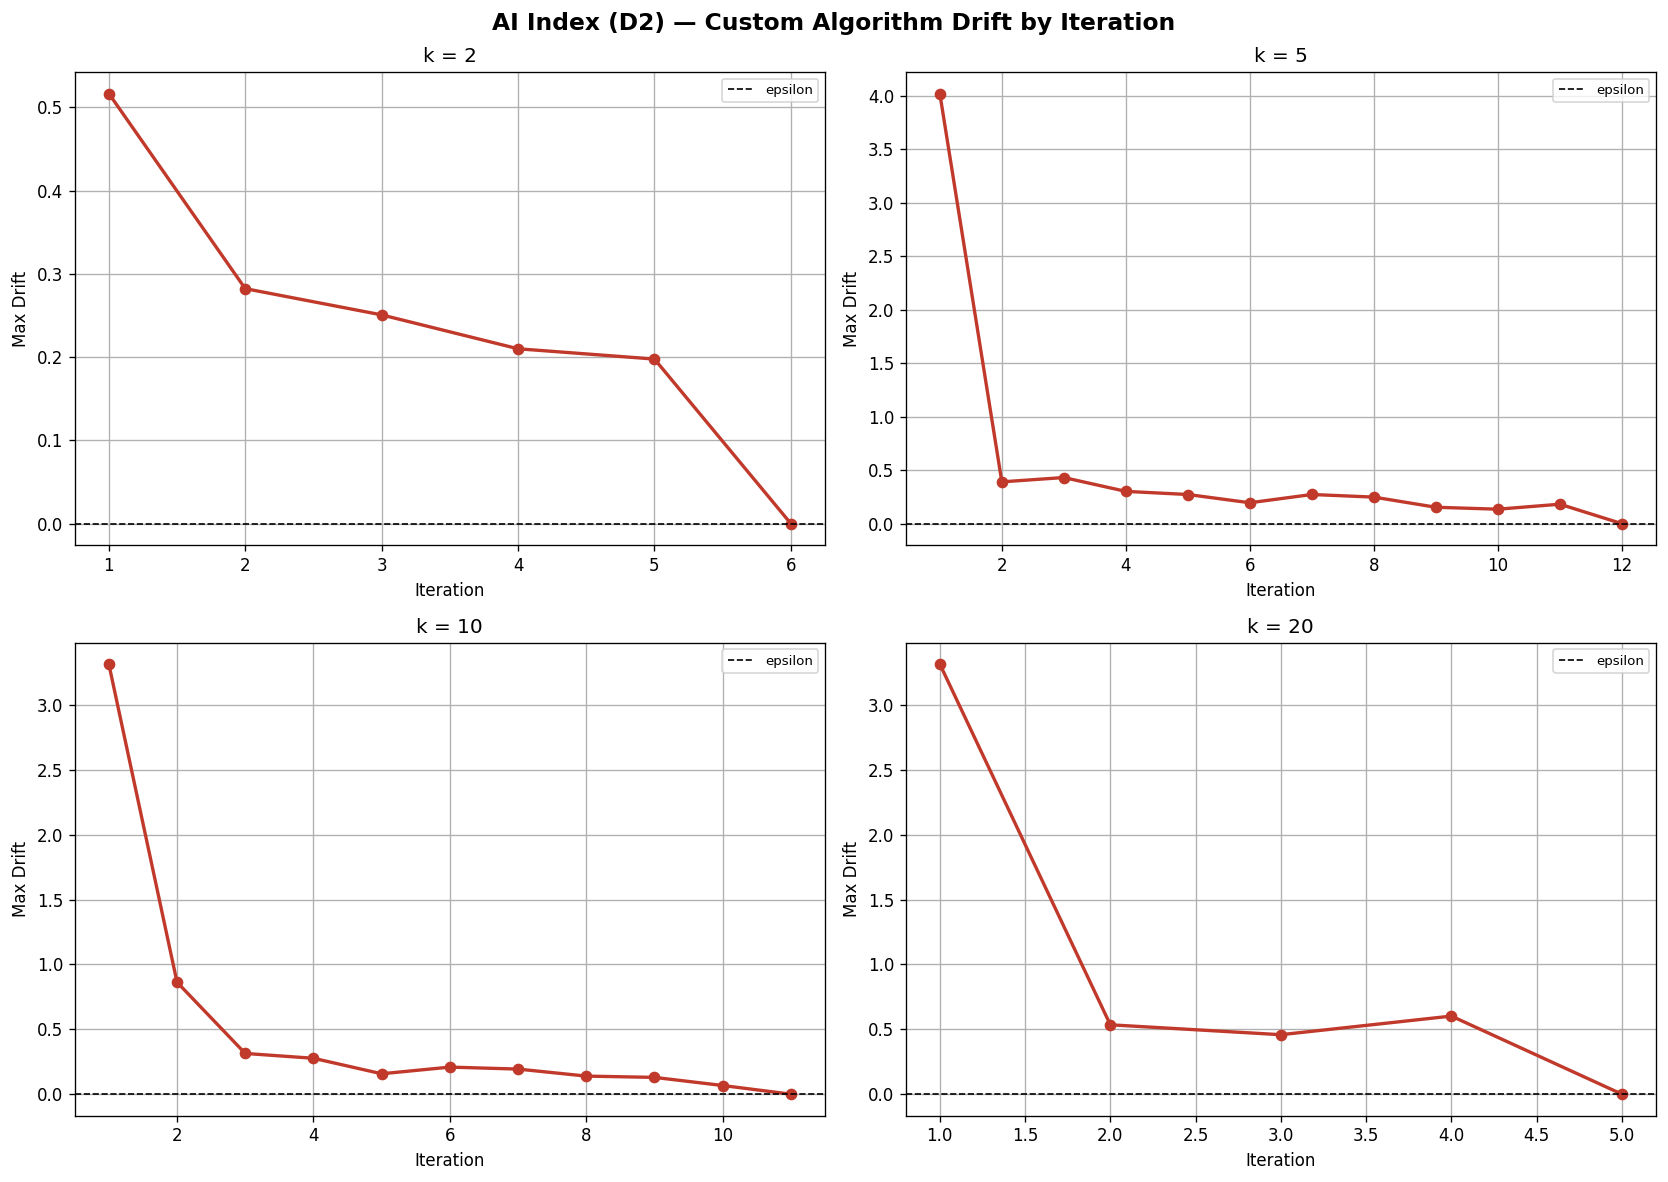

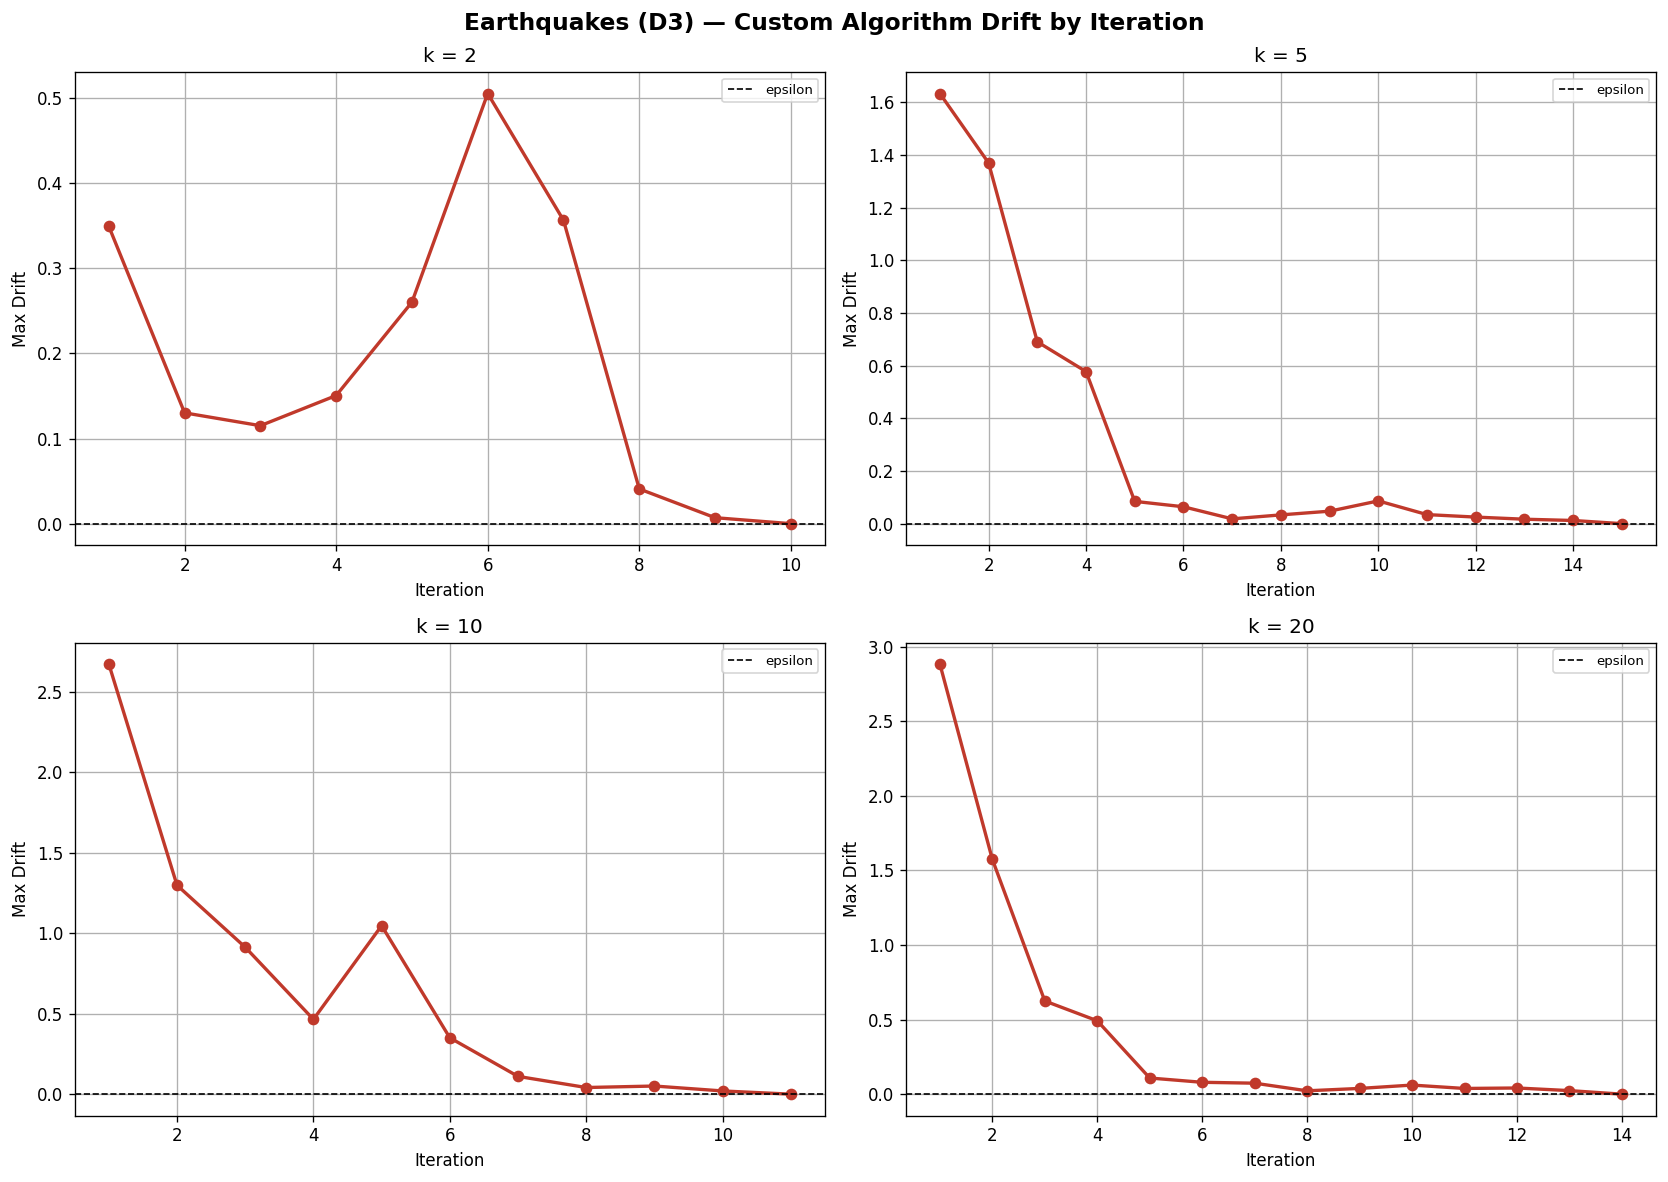

In [9]:
for ds_name in datasets:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{ds_name} — Custom Algorithm Drift by Iteration", fontsize=14, fontweight="bold")

    for idx, k in enumerate(k_values):
        ax = axes[idx // 2, idx % 2]
        hist = all_results[(ds_name, k, "Custom (Final)")]["drift_history"]
        ax.plot(range(1, len(hist) + 1), hist, color=model_colors["Custom (Final)"], marker="o", linewidth=2)
        ax.axhline(1e-4, color="black", linestyle="--", linewidth=1, label="epsilon")
        ax.set_title(f"k = {k}")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Max Drift")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 4.2.5 Runtime Comparison


Saved: figures/Iris_(D1)_runtime_vs_k.png


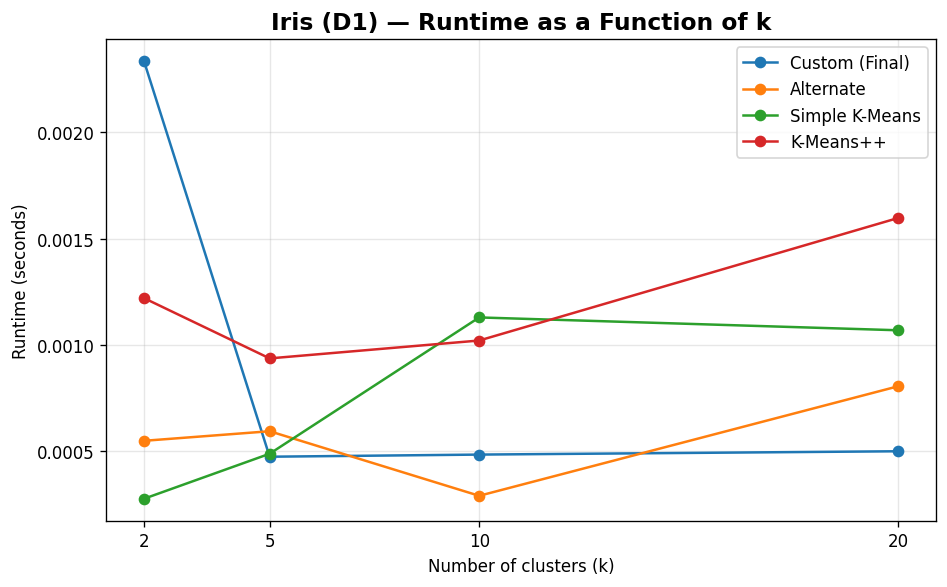

Saved: figures/AI_Index_(D2)_runtime_vs_k.png


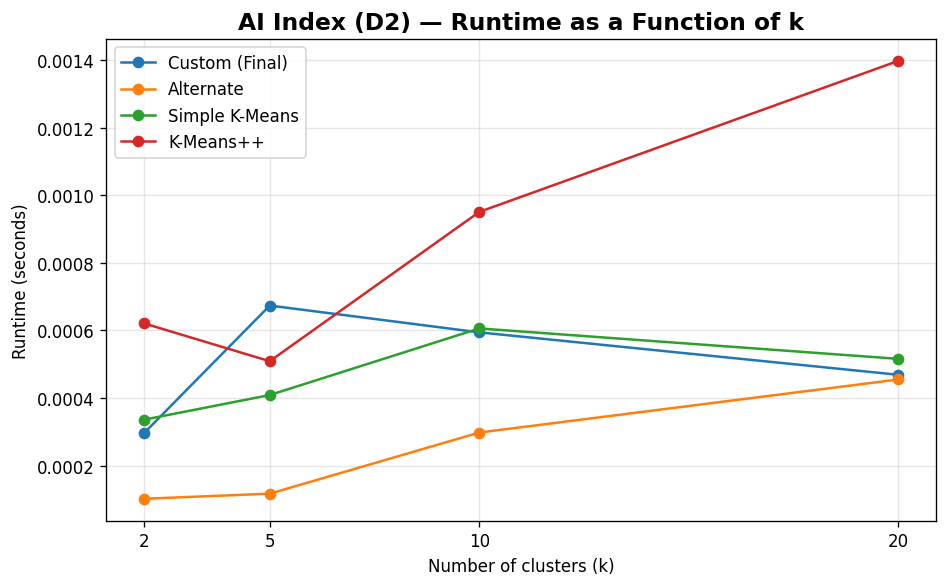

Saved: figures/Earthquakes_(D3)_runtime_vs_k.png


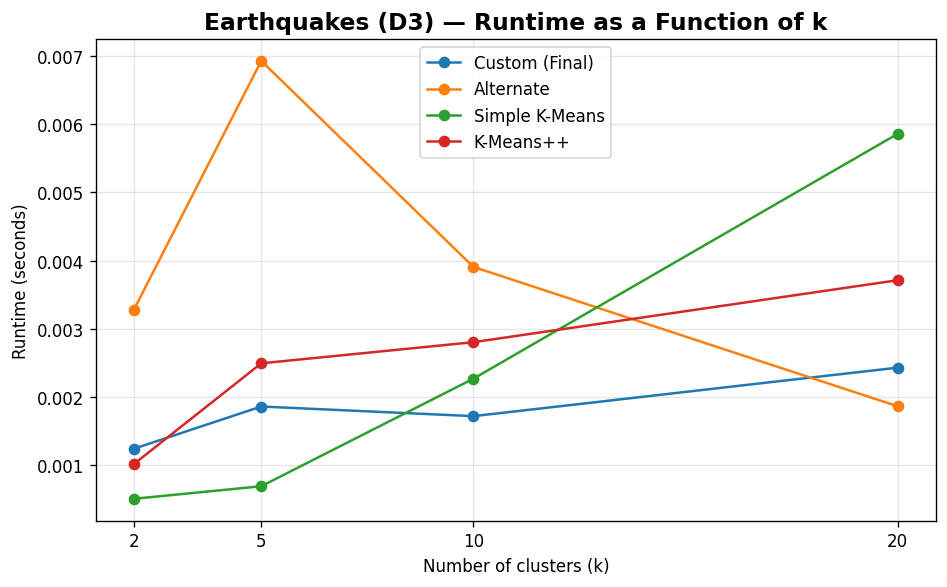

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

runtime_df = pd.DataFrame(runtime_rows)

for ds_name in datasets:
    fig, ax = plt.subplots(figsize=(8, 5))

    subset = runtime_df[runtime_df["Dataset"] == ds_name]

    for model in model_names:
        model_subset = subset[subset["Model"] == model].sort_values("k")
        ax.plot(
            model_subset["k"],
            model_subset["Runtime (s)"],
            marker="o",
            label=model,
        )

    ax.set_title(f"{ds_name} — Runtime as a Function of k", fontsize=14, fontweight="bold")
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel("Runtime (seconds)")
    ax.set_xticks(k_values)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = f"figures/{ds_name.replace(' ', '_')}_runtime_vs_k.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved: {filename}")

    plt.show()

## 4.3 Analysis and Discussion

The analysis below is written for the **final custom algorithm**, not the earlier pruning-based version.


### 4.3.1 Potential Advantages

**Custom (Final)**

- **Deterministic initialization**: dominant-axis percentile-based ESPI initialization removes randomness from the starting centroids, which makes runs reproducible.
- **Simple convergence logic**: the stopping rule is easy to interpret because it depends only on the maximum centroid drift.
- **Stable implementation**: every iteration still performs a full reassignment, so the algorithm does not depend on approximate boundary filtering rules.
- **Consistent behavior across runs**: unlike random initialization, the custom method gives the same result on the same dataset for the same `k`.

**Alternate**

- **Very conservative reassignment**: only one extreme point per cluster is reconsidered each iteration.
- **Gradual label changes**: assignments often change more slowly than in full-reassignment methods.

**Simple K-Means**

- **Direct baseline**: it is the standard textbook algorithm with random initialization.
- **Easy to benchmark**: it gives a clean baseline for measuring SSE and iteration counts.

**K-Means++**

- **Stronger initialization**: k-means++ often starts from better-separated centroids.
- **Good practical performance**: it frequently reaches low SSE in fewer iterations than random initialization.


### 4.3.2 Possible Drawbacks

**Custom (Final)**

- **No assignment pruning**: because every iteration reassigns all points, the final algorithm does not gain the speed benefits of the earlier drift-filtering design.
- **Initialization may still be suboptimal**: dominant-axis percentile placement is reproducible, but it is not guaranteed to be as strong as k-means++.
- **Epsilon sensitivity**: if `epsilon` is set too large, the algorithm can stop early; if it is too small, it may run extra iterations.

**Alternate**

- **Slow convergence**: moving only one candidate point per cluster can require many iterations.
- **May stop in a suboptimal state**: the furthest point heuristic does not guarantee the best next reassignment.

**Simple K-Means**

- **Random seed sensitivity**: poor initial seeds can lead to worse final clusterings.
- **Higher variability**: results may differ from run to run unless the seed is fixed.

**K-Means++**

- **Initialization cost**: it is usually better than random initialization, but more expensive to initialize.
- **Still local-optimum based**: better initialization does not remove the local minimum issue entirely.


### 4.3.3 Interpretation of the Final Custom Algorithm

The key point in the final version is that **drift is no longer a selection rule for points**. It is only used to decide when centroid motion has become small enough to stop. This makes the final algorithm conceptually closer to standard k-means, but with a deterministic initialization strategy and a drift-based stopping condition.

In practice, the final custom algorithm should be interpreted as:

- a deterministic alternative to random initialization
- a simpler alternative to the earlier drift-pruning version
- a direct baseline against k-means++, simple k-means, and the alternate furthest-point method


### 4.3.4 When the Final Custom Algorithm Might Be Preferred

1. **When reproducibility matters**: the initialization is deterministic, so repeated runs are stable without relying on random seeds.
2. **When simpler reasoning is preferred**: the final algorithm is easier to explain and defend because it does not rely on approximate active-point pruning.
3. **When you want a custom variant that stays close to textbook k-means**: the reassignment logic remains standard, while initialization and stopping are customized.
4. **When comparing initialization strategies**: the final custom model is useful for studying whether deterministic dominant-axis ESPI initialization can compete with random initialization and k-means++ on the project datasets.


In [11]:
comparison_summary_df.sort_values(["Dataset", "k", "Final SSE", "Runtime (s)"]).reset_index(drop=True)


,Dataset,k,Model,Iterations,Final SSE,Total Reassignments,Runtime (s),Final Max Drift
0,AI Index (D2),2,Simple K-Means,7,342.3641,19,0.000207,NaN
1,AI Index (D2),2,K-Means++,5,342.3641,10,0.000284,NaN
2,AI Index (D2),2,Custom (Final),6,348.5625,7,0.000199,0.0
3,AI Index (D2),2,Alternate,2,387.4091,1,0.000067,NaN
4,AI Index (D2),5,K-Means++,2,140.4814,7,0.000318,NaN
5,AI Index (D2),5,Custom (Final),12,156.6279,52,0.000343,0.0
6,AI Index (D2),5,Simple K-Means,5,157.2754,9,0.000279,NaN
7,AI Index (D2),5,Alternate,1,166.4562,0,0.000063,NaN
8,AI Index (D2),10,K-Means++,4,81.9138,5,0.000679,NaN
9,AI Index (D2),10,Simple K-Means,5,89.4339,15,0.000419,NaN
